In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import pandas as pd
import copy
import warnings
import seaborn as sns

# Random Forest and feature importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

#SHAP for signed predictor contributions
import shap
import sklearn

/Users/feng045/opt/miniconda3/envs/py312-26.4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# mpl.rcParams['font.family'] = 'STIXGeneral'
# mpl.rcParams['font.family'] = 'DejaVuSans'
mpl.rcParams['font.family'] = 'Helvetica'

print(f"scikit-learn version: {sklearn.__version__}")
print(f"shap version: {shap.__version__}")

scikit-learn version: 1.8.0
shap version: 0.51.0


In [3]:
# Variable names for environmental parameters in the dataset
# Reversible
CAPE_varname = 'CAPE_mu'
EL_varname = 'EL_height_mu'
CAPEacbl_varname = 'CAPEacbl_mu'
CIN_varname = 'CIN_mu'
LFCz_varname = 'LFC_height_mu'

# Figure output directory (RF-specific)
figdir = '/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/'
# figdir = '/Users/feng045/tmp/narrow_wide_CI30min_RF/'
os.makedirs(figdir, exist_ok=True)

# Input directory for pre-filtered combined datasets
# input_dir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined_coldpool+2h'
input_dir = '/Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min'

# Time resolution [minutes]
time_res = 5.0

# Domain 4 boundaries
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000] # [minutes]

### Random Forest hyperparameters

In [4]:
RF_N_ESTIMATORS = 500
RF_MAX_FEATURES = 0.7 # decorrelates trees; sklearn 1.8 default for regression is 1.0
RF_MIN_SAMPLES_LEAF = 5 # regularize; critical for D2-wide (n≈99)
RF_RANDOM_STATE = 42
RF_N_BOOT_RF = 50 # number of RF seeds for bootstrap importance stability (D2-wide small-n mitigation)

# rf_bydiam parameters
MIN_SAMPLES_PER_BIN = 15 # skip bin if fewer samples than this

### Filter thresholds

In [5]:
MULNB_thresh = 6.0 # MU LNB > this [km]
max_Wbase_LCL_dist = 2.0 # [km]
min_Wtop_slope = 0

## Load pre-filtered datasets directly into memory

In [6]:
# Load pre-filtered datasets directly into memory (avoid Dask for faster operations)
print("Loading pre-filtered combined datasets into memory...")

# Load D2 (2.5 km domain) - load() loads into memory immediately
file_d2 = f'{input_dir}/stats_combined_filtered_d2.nc'
print(f"Loading: {file_d2}")
# Drop 'height' dimension as it's not needed for this analysis
dsnms_d2 = xr.open_dataset(file_d2).drop_dims('height').load()  # .load() brings all data into memory
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
print(f"  D2 filtered tracks: {ntracks_nms_d2}")

# Load D3 domain
file_d3 = f'{input_dir}/stats_combined_filtered_d3.nc'
print(f"Loading: {file_d3}")
# Drop 'height' dimension as it's not needed for this analysis
dsnms_d3 = xr.open_dataset(file_d3).drop_dims('height').load()
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
print(f"  D3 filtered tracks: {ntracks_nms_d3}")

# Load D4 domain
file_d4 = f'{input_dir}/stats_combined_filtered_d4.nc'
print(f"Loading: {file_d4}")
# Drop 'height' dimension as it's not needed for this analysis
dsnms_d4 = xr.open_dataset(file_d4).drop_dims('height').load()
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f"  D4 filtered tracks: {ntracks_nms_d4}")

print("\nAll datasets loaded into memory successfully!")
print(f"Total filtered tracks: {ntracks_nms_d2 + ntracks_nms_d3 + ntracks_nms_d4}")

# Display memory usage
mem_d2 = sum(var.nbytes for var in dsnms_d2.variables.values()) / 1e9
mem_d3 = sum(var.nbytes for var in dsnms_d3.variables.values()) / 1e9
mem_d4 = sum(var.nbytes for var in dsnms_d4.variables.values()) / 1e9
print(f"\nMemory usage:")
print(f"  D2: {mem_d2:.2f} GB")
print(f"  D3: {mem_d3:.2f} GB")
print(f"  D4: {mem_d4:.2f} GB")
print(f"  Total: {mem_d2 + mem_d3 + mem_d4:.2f} GB")

Loading pre-filtered combined datasets into memory...
Loading: /Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min/stats_combined_filtered_d2.nc
  D2 filtered tracks: 646
Loading: /Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min/stats_combined_filtered_d3.nc
  D3 filtered tracks: 1315
Loading: /Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min/stats_combined_filtered_d4.nc
  D4 filtered tracks: 1202

All datasets loaded into memory successfully!
Total filtered tracks: 3163

Memory usage:
  D2: 0.50 GB
  D3: 1.01 GB
  D4: 0.92 GB
  Total: 2.43 GB


In [7]:
dsnms_d4

<xarray.Dataset> Size: 925MB
Dimensions:                  (tracks: 1202, times: 200, z: 40)
Coordinates:
  * tracks                   (tracks) int64 10kB 0 2 3 5 ... 1705 1706 1708 1709
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
    core                     int64 8B 0
Data variables: (12/187)
    track_duration           (tracks) int32 5kB 14 7 5 3 8 6 15 ... 10 4 6 4 6 3
    base_time                (tracks, times) datetime64[ns] 2MB 2018-11-29T13...
    meanlat                  (tracks, times) float32 962kB -32.74 -32.74 ... nan
    meanlon                  (tracks, times) float32 962kB -64.9 -64.9 ... nan
    area                     (tracks, times) float32 962kB 16.75 15.5 ... nan
    cloudnumber              (tracks, times) float64 2MB 1.0 1.0 1.0 ... nan nan
    ...                       ...
    shear_mag_bulk_0to9km    (tracks) float32 5kB 32.76 48.61 ... 32.95 27.75
    shear_dir_bulk_0to9km    (tracks) float32 5kB 294.9 294.7 ... 280.6 270.6
    Ucrel_mean_ACBL_mu       (tracks) float32 5kB 0.7807 2.497 ... -2.707 1.213
    Vcrel_mean_ACBL_mu       (tracks) float32 5kB -1.09 -4.207 ... -12.3 2.799
    Z_surface                (tracks) float32 5kB 1.292e+03 2.02e+03 ... 512.6
    original_tracks          (tracks) int64 10kB 0 5 10 14 ... 343 345 354 357
Attributes: (12/15)
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    ...                    ...
    time_start:            0
    time_end:              60
    time_environment:      -1
    ETH_buffer:            1.0
    cbase_depth:           0.5
    coldpool_time_offset:  2.0

In [8]:
dsnms_d4.Warea_max_CI.attrs

{'long_name': 'Cloud base max updraft core area within CI period',
 'units': 'km^2',
 'CI_time_window': array([ 0., 30.])}

### Extract common coordinates and time window

In [9]:
xtime = dsnms_d2.times * time_res
height_core = dsnms_d2.z
time_window = (dsnms_d2.attrs['time_start'], dsnms_d2.attrs['time_end'])

ntimes = dsnms_d2.sizes['times']
nz = dsnms_d2.sizes['z']
time_coord = dsnms_d2.times
xtime = time_coord * time_res # [min]

tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()

print(f"Time window: {time_window} minutes")
print(f"tidx_start={tidx_start}, tidx_end={tidx_end}")

Time window: (np.int64(0), np.int64(60)) minutes
tidx_start=0, tidx_end=12


/Users/feng045/opt/miniconda3/envs/py312-26.4/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/feng045/opt/miniconda3/envs/py312-26.4/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


In [10]:
# Subset DataSet to CI time_window and derive cell statistics
dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_d2 = dsCI_d2['max_dbz'].load()
maxdbz_d3 = dsCI_d3['max_dbz'].load()
maxdbz_d4 = dsCI_d4['max_dbz'].load()

# Cell ETH
maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()

# Cell diameter
cellarea_d2 = dsCI_d2['cell_area'].load()
cellarea_d3 = dsCI_d3['cell_area'].load()
cellarea_d4 = dsCI_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

# Max updraft top height
trackmaxWtop_d2 = dsCI_d2['Wtop'].max(dim='times')
trackmaxWtop_d3 = dsCI_d3['Wtop'].max(dim='times')
trackmaxWtop_d4 = dsCI_d4['Wtop'].max(dim='times')

# Max updraft diameter
maxWdiam_d2 = 2 * np.sqrt(dsCI_d2['Warea_max']/np.pi)
maxWdiam_d3 = 2 * np.sqrt(dsCI_d3['Warea_max']/np.pi)
maxWdiam_d4 = 2 * np.sqrt(dsCI_d4['Warea_max']/np.pi)

# Max updraft diameter during CI window
maxWdiam_CI_d2 = 2 * np.sqrt(dsCI_d2['Warea_max_CI']/np.pi)
maxWdiam_CI_d3 = 2 * np.sqrt(dsCI_d3['Warea_max_CI']/np.pi)
maxWdiam_CI_d4 = 2 * np.sqrt(dsCI_d4['Warea_max_CI']/np.pi)

# Time of max W diameter
maxWdiam_time_d2 = dsCI_d2['Warea_max_time'] * time_res
maxWdiam_time_d3 = dsCI_d3['Warea_max_time'] * time_res
maxWdiam_time_d4 = dsCI_d4['Warea_max_time'] * time_res
maxWdiam_time_CI_d2 = dsCI_d2['Warea_max_time_CI'] * time_res
maxWdiam_time_CI_d3 = dsCI_d3['Warea_max_time_CI'] * time_res
maxWdiam_time_CI_d4 = dsCI_d4['Warea_max_time_CI'] * time_res

# Time of max ETH / max Wtop
trackmaxWtop_time_d2 = dsCI_d2['Wtop'].idxmax(dim='times', skipna=True) * time_res
trackmaxWtop_time_d3 = dsCI_d3['Wtop'].idxmax(dim='times', skipna=True) * time_res
trackmaxWtop_time_d4 = dsCI_d4['Wtop'].idxmax(dim='times', skipna=True) * time_res
trackmaxETH_10dbz_time_d2 = maxETH_10dbz_d2.idxmax(dim='times', skipna=True) * time_res
trackmaxETH_10dbz_time_d3 = maxETH_10dbz_d3.idxmax(dim='times', skipna=True) * time_res
trackmaxETH_10dbz_time_d4 = maxETH_10dbz_d4.idxmax(dim='times', skipna=True) * time_res

# Updraft lifetime
Wlifetime_d2 = dsCI_d2['Wlifetime'].load()
Wlifetime_d3 = dsCI_d3['Wlifetime'].load()
Wlifetime_d4 = dsCI_d4['Wlifetime'].load()

In [11]:
# CI-max cell values
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
trackmaxdbz_d2 = maxdbz_d2.max(dim='times')

trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
trackmaxdbz_d3 = maxdbz_d3.max(dim='times')

trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
trackmaxdbz_d4 = maxdbz_d4.max(dim='times')

In [12]:
# Add CI-period variables to DataSet
for ds, trackmaxCellDiam, trackmaxETH, trackmaxdbz, maxWdiam, trackmaxWtop, maxWdiam_time, trackmaxWtop_time, maxWdiam_CI, maxWdiam_time_CI, trackmaxETH_time in [
(dsnms_d2, trackmaxCellDiam_d2, trackmaxETH_10dbz_d2, trackmaxdbz_d2, maxWdiam_d2, trackmaxWtop_d2, maxWdiam_time_d2, trackmaxWtop_time_d2, maxWdiam_CI_d2, maxWdiam_time_CI_d2, trackmaxETH_10dbz_time_d2),
(dsnms_d3, trackmaxCellDiam_d3, trackmaxETH_10dbz_d3, trackmaxdbz_d3, maxWdiam_d3, trackmaxWtop_d3, maxWdiam_time_d3, trackmaxWtop_time_d3, maxWdiam_CI_d3, maxWdiam_time_CI_d3, trackmaxETH_10dbz_time_d3),
(dsnms_d4, trackmaxCellDiam_d4, trackmaxETH_10dbz_d4, trackmaxdbz_d4, maxWdiam_d4, trackmaxWtop_d4, maxWdiam_time_d4, trackmaxWtop_time_d4, maxWdiam_CI_d4, maxWdiam_time_CI_d4, trackmaxETH_10dbz_time_d4),
]:
    ds['CImaxCellDiam'] = trackmaxCellDiam
    ds['CImaxETH_10dbz'] = trackmaxETH
    ds['CImaxdbz'] = trackmaxdbz
    ds['CImaxWDiam'] = maxWdiam
    ds['CImaxWTop'] = trackmaxWtop
    ds['CImaxWDiamTime'] = maxWdiam_time
    ds['CImaxWTopTime'] = trackmaxWtop_time
    ds['CImaxWDiam_CI'] = maxWdiam_CI
    ds['CImaxWDiamTime_CI'] = maxWdiam_time_CI
    ds['CImaxETH10dbzTime'] = trackmaxETH_time

In [13]:
# Get pre-CI MU LNB
MULNB_d2 = dsnms_d2.EL_height_mu / 1000
MULNB_d3 = dsnms_d3.EL_height_mu / 1000
MULNB_d4 = dsnms_d4.EL_height_mu / 1000

def filter_LNB_Wbase(ds, MULNB_thresh, max_Wbase_LCL_dist):
    track_idx = (((ds.EL_height_mu/1000) > MULNB_thresh) & (ds.Wbase_LCL_diff <= max_Wbase_LCL_dist)).compute()
    ds_out = ds.sel(tracks=track_idx)
    return ds_out

dsfilt_d2 = filter_LNB_Wbase(dsnms_d2, MULNB_thresh, max_Wbase_LCL_dist)
dsfilt_d3 = filter_LNB_Wbase(dsnms_d3, MULNB_thresh, max_Wbase_LCL_dist)
dsfilt_d4 = filter_LNB_Wbase(dsnms_d4, MULNB_thresh, max_Wbase_LCL_dist)

ntracks_filt_d2 = dsfilt_d2.sizes['tracks']
ntracks_filt_d3 = dsfilt_d3.sizes['tracks']
ntracks_filt_d4 = dsfilt_d4.sizes['tracks']

print(f'D2 filtered tracks: {ntracks_filt_d2} ({100*ntracks_filt_d2/ntracks_nms_d2:.0f}%)')
print(f'D3 filtered tracks: {ntracks_filt_d3} ({100*ntracks_filt_d3/ntracks_nms_d3:.0f}%)')
print(f'D4 filtered tracks: {ntracks_filt_d4} ({100*ntracks_filt_d4/ntracks_nms_d4:.0f}%)')

D2 filtered tracks: 615 (95%)
D3 filtered tracks: 1261 (96%)
D4 filtered tracks: 1070 (89%)


In [14]:
def standardize_var(var):
    return (var - np.nanmean(var)) / np.nanstd(var)

def find_closest_percentile(data, target_value, precision=100):
    data = data[~np.isnan(data)]
    quantiles = np.linspace(0, 1, precision + 1)
    quantile_values = np.quantile(data, quantiles)
    closest_quantile_index = np.argmin(np.abs(quantile_values - target_value))
    closest_percentile = quantiles[closest_quantile_index] * 100
    closest_quantile_value = quantile_values[closest_quantile_index]
    return closest_percentile, closest_quantile_value

In [15]:
# Variable names to include in the Pandas Data Frame
names = ['Max 10dBZ ETH', 'Max W Top', 'Max W Diameter', 'CI-Max W Diameter', r'$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']

# Predictor names used in rf_bydiam
predictor_names = ['CI W Diameter', r'$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']

## Random Forest: `rf_bydiam`

In [16]:
def rf_bydiam(ds, bin_edges, predictor_names, predictant_name='Max 10dBZ ETH',
                n_estimators=RF_N_ESTIMATORS, max_features=RF_MAX_FEATURES,
                min_samples_leaf=RF_MIN_SAMPLES_LEAF, random_state=RF_RANDOM_STATE,
                n_boot_rf=RF_N_BOOT_RF, min_samples_per_bin=MIN_SAMPLES_PER_BIN):
    """
    Fit RandomForestRegressor in each cell-diameter bin and return MDI importances.
    Parameters
    ----------
    ds : xarray.Dataset
        Filtered dataset containing cell and environmental variables.
    bin_edges : array-like
        Edges defining the cell-diameter bins.
    predictor_names : list of str
        Names of predictors — must match DataFrame column names built inside the function.
    predictant_name : str
        Name of the predictand ('Max 10dBZ ETH' or 'Max W Top').
    n_estimators, max_features, min_samples_leaf, random_state : RF hyperparameters.
    n_boot_rf : int
        Number of RF seeds for bootstrap stability of importances.
    min_samples_per_bin : int
        Bins with fewer samples than this are skipped (filled with NaN).

    Returns
    -------
    importances_mean : ndarray, shape (nbins, npredictors)
        Mean MDI importance (%) across RF seeds.
    importances_std : ndarray, shape (nbins, npredictors)
        Std of MDI importance (%) across RF seeds.
    oob_r2 : ndarray, shape (nbins,)
        Mean OOB r² across RF seeds.
    r2_insample : ndarray, shape (nbins,)
        In-sample r² (mean across RF seeds).
    """
    nbins = len(bin_edges) - 1
    npredictors = len(predictor_names)

    importances_mean = np.full([nbins, npredictors], np.nan)
    importances_std  = np.full([nbins, npredictors], np.nan)
    oob_r2           = np.full(nbins, np.nan)
    r2_insample      = np.full(nbins, np.nan)

    for k in range(nbins):
        diam_ind = np.where(
            np.logical_and(ds.CImaxCellDiam >= bin_edges[k],
                        ds.CImaxCellDiam <  bin_edges[k+1])
        )[0]

        if len(diam_ind) < min_samples_per_bin:
            print(f'  bin {k} ({bin_edges[k]:.1f}–{bin_edges[k+1]:.1f} km): only {len(diam_ind)} samples — skipped')
            continue

        # Build DataFrame (same variable assignments as mlr_bydiam, NO standardization)
        df = pd.DataFrame()
        df['Max 10dBZ ETH']       = ds['CImaxETH_10dbz'].isel(tracks=diam_ind).values
        df['Max W Top']           = ds['CImaxWTop'].isel(tracks=diam_ind).values
        df['Max W Diameter']      = ds['CImaxWDiam'].isel(tracks=diam_ind).values
        df['CI W Diameter']       = ds['CImaxWDiam_CI'].isel(tracks=diam_ind).values
        df[r'$\sqrt{2*MUCAPE}$']   = np.sqrt(2 * ds[CAPE_varname].isel(tracks=diam_ind).values)
        df['MU LCL Height']       = ds['LCL_height_mu'].isel(tracks=diam_ind).values
        df['600 hPa RH']          = ds['rh_600mb'].isel(tracks=diam_ind).values
        df['0-3 km BWD']          = ds['shear_mag_bulk_0to3km'].isel(tracks=diam_ind).values

        # Drop rows with any NaN in selected columns
        cols_needed = predictor_names + [predictant_name]
        df_clean = df[cols_needed].dropna()

        if len(df_clean) < min_samples_per_bin:
            print(f'  bin {k}: after NaN drop only {len(df_clean)} samples — skipped')
            continue

        X = df_clean[predictor_names].to_numpy()
        y = df_clean[predictant_name].to_numpy()

        # Bootstrap across RF seeds
        boot_importances = np.full([n_boot_rf, npredictors], np.nan)
        boot_oob_r2      = np.full(n_boot_rf, np.nan)
        boot_r2_in       = np.full(n_boot_rf, np.nan)

        for b in range(n_boot_rf):
            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_features=max_features,
                min_samples_leaf=min_samples_leaf,
                oob_score=True,
                random_state=random_state + b,
            )
            rf.fit(X, y)
            boot_importances[b, :] = rf.feature_importances_ * 100
            boot_oob_r2[b]         = rf.oob_score_
            boot_r2_in[b]          = r2_score(y, rf.predict(X))

        importances_mean[k, :] = np.mean(boot_importances, axis=0)
        importances_std[k, :]  = np.std(boot_importances, axis=0)
        oob_r2[k]              = np.mean(boot_oob_r2)
        r2_insample[k]         = np.mean(boot_r2_in)

    return importances_mean, importances_std, oob_r2, r2_insample

## Function to plot predictor importance by cell diameter bins

In [17]:
def heatmap_MxN(nrow, ncol, data_arr, xedges, yedges, predictor_names, xedges_threshs=None, narrow_threshs=None, wide_threshs=None,
                wspace=None, hspace=None, cmap=None, vmin=None, vmax=None, cblabels=None, cbticks=None,
                xlims=None, ylims=None, xlabels=None, ylabels=None, suptitle=None,
                titles=None, fontsize=None, figsize=None, figname=None, dpi=None, hist_data=None):

    mpl.rcParams['font.size'] = fontsize

    fig = plt.figure(figsize=figsize, dpi=dpi)

    # Setup 3 rows (top: histograms, middle: heatmaps, bottom: colorbar) if hist_data provided
    if hist_data is not None:
        gs0 = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[0.3, 1, 0.03], width_ratios=[1], hspace=hspace)
        # Histogram row
        gs_hist = gridspec.GridSpecFromSubplotSpec(1, ncol, subplot_spec=gs0[0], wspace=wspace)
        # Heatmap row  
        gs_main = gs0[1]
    else:
        # Original 2-row layout if no histogram data
        gs0 = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 0.03], width_ratios=[1], hspace=hspace)
        gs_main = gs0[0]
    
    # Colorbar
    cax = plt.subplot(gs0[-1])
    
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs_main, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    
    # Create histograms if data provided
    if hist_data is not None:
        for pp in range(ncol):
            ax_hist = plt.subplot(gs_hist[pp])
            # Plot histogram using the provided data and bin edges
            ax_hist.hist(hist_data[pp], bins=xedges[pp], edgecolor='black', alpha=0.7, color='lightblue')
            if (pp == 0): ax_hist.set_ylabel('Sample Size')
            ax_hist.grid(True, ls=':', alpha=0.5)
            # Remove x-axis labels for histogram (will be shown on heatmap below)
            ax_hist.set_xticklabels([])
            ax_hist.set_xlim(np.min(xedges[pp]), np.max(xedges[pp]))
            # Add vertical lines for thresholds if provided
            if narrow_threshs is not None:
                ax_hist.axvline(x=narrow_threshs[pp], ls='-', lw=2, color='red', alpha=0.7)
            if wide_threshs is not None:
                ax_hist.axvline(x=wide_threshs[pp], ls='--', lw=2, color='red', alpha=0.7)
    
    # Loop over rows and columns for heatmaps
    for pp in range(nrow*ncol):
        idata = data_arr[pp]
        X = xedges[pp]
        Y = yedges[pp]
        if (pp == 0):
            yticklabels = predictor_names
        else:
            yticklabels = ['']*len(predictor_names)          
        
        ax = plt.subplot(gs[pp])
        pcm = ax.pcolormesh(X, Y, idata, vmin=vmin, vmax=vmax, cmap=cmap)
        if xedges_threshs is not None:
            ax.axvline(x=xedges_threshs[pp], ls='--', lw=2, color='w')
        if narrow_threshs is not None:
            ax.axvline(x=narrow_threshs[pp], ls='-', lw=2, color='w')
        if wide_threshs is not None:
            ax.axvline(x=wide_threshs[pp], ls='--', lw=2, color='w')
        yticks = Y[:-1] + np.diff(Y)*0.5
        ax.set_yticks(yticks, labels=yticklabels, rotation=45)
        ax.set_xlabel(xlabels[pp])
        ax.set_ylabel(ylabels[pp])
        ax.set_title(titles[pp], loc='left')
    
    # Colorbar
    cbar = plt.colorbar(pcm, cax=cax, label=cblabels, ticks=cbticks, orientation='horizontal', extend='both')
    # Suptitle
    fig.suptitle(suptitle, weight='bold', y=0.93, fontsize=fontsize*1.5)
    
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

## Narrow vs. Wide cell diameter threshold configuration
Set threshold_mode to choose between two approaches:

- `rf`: Use thresholds identified from visual inspection of the RF importance heatmap above (recommended — thresholds are physically motivated by where predictor importance shifts).
- `fixed_percentile`: Use a common percentile across all 3 resolutions (useful for sensitivity tests).

In [18]:
# CHOOSE THRESHOLD MODE
# ============================================================
# threshold_mode = 'rf' # 'rf' or 'fixed_percentile'
threshold_mode = 'fixed_percentile'

# Used only when threshold_mode == 'fixed_percentile'
narrow_qt_fixed = 0.65
wide_qt_fixed = 0.85

In [19]:
if threshold_mode == 'rf':
    # ---- Define cell-diameter bin edges ----
    bin_edges_d2 = np.array([6, 8.5, 9.8, 11.3, 13, 16, 19, 40])
    bin_edges_d3 = np.array([3.9, 4.8, 6, 7.2, 9, 11.5, 15, 30])
    bin_edges_d4 = np.array([3.9, 4.8, 6, 7.2, 9, 11.5, 15, 30])

    # ---- Run rf_bydiam for Max 10dBZ ETH ----
    print("Running rf_bydiam for Max 10dBZ ETH...")
    predictant_name = 'Max 10dBZ ETH'
    ETH_imp_mean_d2, ETH_imp_std_d2, ETH_oob_r2_d2, ETH_r2in_d2 = rf_bydiam(dsfilt_d2, bin_edges_d2, predictor_names, predictant_name=predictant_name)
    print("D2 done")
    ETH_imp_mean_d3, ETH_imp_std_d3, ETH_oob_r2_d3, ETH_r2in_d3 = rf_bydiam(dsfilt_d3, bin_edges_d3, predictor_names, predictant_name=predictant_name)
    print("D3 done")
    ETH_imp_mean_d4, ETH_imp_std_d4, ETH_oob_r2_d4, ETH_r2in_d4 = rf_bydiam(dsfilt_d4, bin_edges_d4, predictor_names, predictant_name=predictant_name)
    print("D4 done")

    # ---- Run rf_bydiam for Max W Top (optional) ----
    # print("Running rf_bydiam for Max W Top...")
    # predictant_name = 'Max W Top'
    # WTop_imp_mean_d2, WTop_imp_std_d2, WTop_oob_r2_d2, WTop_r2in_d2 = rf_bydiam(dsfilt_d2, bin_edges_d2, predictor_names, predictant_name=predictant_name)
    # print("D2 done")
    # WTop_imp_mean_d3, WTop_imp_std_d3, WTop_oob_r2_d3, WTop_r2in_d3 = rf_bydiam(dsfilt_d3, bin_edges_d3, predictor_names, predictant_name=predictant_name)
    # print("D3 done")
    # WTop_imp_mean_d4, WTop_imp_std_d4, WTop_oob_r2_d4, WTop_r2in_d4 = rf_bydiam(dsfilt_d4, bin_edges_d4, predictor_names, predictant_name=predictant_name)
    # print("D4 done")

    # ---- Plot RF predictor importances heatmap ----
    # Inspect this plot to choose narrow/wide cutoffs below
    nrow = 1
    ncol = 3
    data_arr_hm = [ETH_imp_mean_d2.T, ETH_imp_mean_d3.T, ETH_imp_mean_d4.T]
    xedges_hm = [bin_edges_d2, bin_edges_d3, bin_edges_d4]
    yedge = np.arange(len(predictor_names) + 1)
    yedges_hm = [yedge] * ncol

    # === PICK THRESHOLDS: inspect heatmap to choose narrow/wide cutoffs ===
    narrow_thresh_d2 = bin_edges_d2[-4]
    narrow_thresh_d3 = bin_edges_d3[-5]
    narrow_thresh_d4 = bin_edges_d4[-5]
    narrow_threshs = [narrow_thresh_d2, narrow_thresh_d3, narrow_thresh_d4]

    wide_thresh_d2 = bin_edges_d2[-3]
    wide_thresh_d3 = bin_edges_d3[-4]
    wide_thresh_d4 = bin_edges_d4[-4]
    wide_threshs = [wide_thresh_d2, wide_thresh_d3, wide_thresh_d4]

    hist_data = [dsnms_d2['CImaxCellDiam'], dsnms_d3['CImaxCellDiam'], dsnms_d4['CImaxCellDiam']]

    cmap_hm = 'plasma'
    vmin, vmax = 0, 80
    cblabels = 'RF MDI Importance (%)'
    cbticks = np.arange(vmin, vmax + 1, 10)
    xlabels_hm = ['Max Cell Diameter (km)'] * ncol
    ylabels_hm = ['Predictors', '', '']
    suptitle_hm = 'RF Predictor Importance for Max 10-dBZ ETH'
    titles_hm = ['(a) D2 (2.5 km)', '(b) D3 (500 m)', '(c) D4 (100 m)']
    figname_hm = f"{figdir}RF_MaxETH_Predictor_Importances_byCellMaxDiameter.png"
    print(figname_hm)
    fig = heatmap_MxN(nrow, ncol, data_arr_hm, xedges_hm, yedges_hm, predictor_names,
                      narrow_threshs=narrow_threshs, wide_threshs=wide_threshs,
                      cmap=cmap_hm, vmin=vmin, vmax=vmax, cblabels=cblabels, cbticks=cbticks,
                      xlabels=xlabels_hm, ylabels=ylabels_hm, titles=titles_hm, suptitle=suptitle_hm,
                      wspace=0.15, hspace=0.3, fontsize=12, figsize=(14, 8),
                      figname=figname_hm, dpi=300, hist_data=hist_data)

    # ---- Assign to common downstream variable names ----
    narrow_diam_d2 = narrow_thresh_d2
    narrow_diam_d3 = narrow_thresh_d3
    narrow_diam_d4 = narrow_thresh_d4
    wide_diam_d2 = wide_thresh_d2
    wide_diam_d3 = wide_thresh_d3
    wide_diam_d4 = wide_thresh_d4

elif threshold_mode == 'fixed_percentile':
    narrow_diam_d2 = dsfilt_d2.CImaxCellDiam.quantile(narrow_qt_fixed).item()
    narrow_diam_d3 = dsfilt_d3.CImaxCellDiam.quantile(narrow_qt_fixed).item()
    narrow_diam_d4 = dsfilt_d4.CImaxCellDiam.quantile(narrow_qt_fixed).item()
    wide_diam_d2 = dsfilt_d2.CImaxCellDiam.quantile(wide_qt_fixed).item()
    wide_diam_d3 = dsfilt_d3.CImaxCellDiam.quantile(wide_qt_fixed).item()
    wide_diam_d4 = dsfilt_d4.CImaxCellDiam.quantile(wide_qt_fixed).item()
else:
    raise ValueError(f"Unknown threshold_mode: {threshold_mode!r}. Use 'rf' or 'fixed_percentile'.")

print(f"Threshold mode: {threshold_mode}")
print(f"Narrow thresholds: D2={narrow_diam_d2:.2f} km, D3={narrow_diam_d3:.2f} km, D4={narrow_diam_d4:.2f} km")
print(f"Wide thresholds:   D2={wide_diam_d2:.2f} km, D3={wide_diam_d3:.2f} km, D4={wide_diam_d4:.2f} km")


Threshold mode: fixed_percentile
Narrow thresholds: D2=12.62 km, D3=7.36 km, D4=6.82 km
Wide thresholds:   D2=15.71 km, D3=10.63 km, D4=9.82 km


In [20]:
# Report closest percentile for each threshold (informational)
narrow_qt_d2, narrow_qt_thresh_d2 = find_closest_percentile(dsfilt_d2.CImaxCellDiam.data, narrow_diam_d2, precision=20)
narrow_qt_d3, narrow_qt_thresh_d3 = find_closest_percentile(dsfilt_d3.CImaxCellDiam.data, narrow_diam_d3, precision=20)
narrow_qt_d4, narrow_qt_thresh_d4 = find_closest_percentile(dsfilt_d4.CImaxCellDiam.data, narrow_diam_d4, precision=20)
wide_qt_d2, wide_qt_thresh_d2 = find_closest_percentile(dsfilt_d2.CImaxCellDiam.data, wide_diam_d2, precision=20)
wide_qt_d3, wide_qt_thresh_d3 = find_closest_percentile(dsfilt_d3.CImaxCellDiam.data, wide_diam_d3, precision=20)
wide_qt_d4, wide_qt_thresh_d4 = find_closest_percentile(dsfilt_d4.CImaxCellDiam.data, wide_diam_d4, precision=20)

print(f'D2 narrow: {narrow_diam_d2:.2f} km ≈ {narrow_qt_d2:.0f}th percentile')
print(f'D3 narrow: {narrow_diam_d3:.2f} km ≈ {narrow_qt_d3:.0f}th percentile')
print(f'D4 narrow: {narrow_diam_d4:.2f} km ≈ {narrow_qt_d4:.0f}th percentile')
print(f'D2 wide: {wide_diam_d2:.2f} km ≈ {wide_qt_d2:.0f}th percentile')
print(f'D3 wide: {wide_diam_d3:.2f} km ≈ {wide_qt_d3:.0f}th percentile')
print(f'D4 wide: {wide_diam_d4:.2f} km ≈ {wide_qt_d4:.0f}th percentile')

D2 narrow: 12.62 km ≈ 65th percentile
D3 narrow: 7.36 km ≈ 65th percentile
D4 narrow: 6.82 km ≈ 65th percentile
D2 wide: 15.71 km ≈ 85th percentile
D3 wide: 10.63 km ≈ 85th percentile
D4 wide: 9.82 km ≈ 85th percentile


### Separate narrow and wide DataSets — D2

In [21]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d2 = ((trackmaxCellDiam_d2 < narrow_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                    # & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                    & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                  & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}, {ntracks_narrow_d2/dsnms_d2.sizes["tracks"]*100:.0f}% of total')
print(f'Number of wide cells (D2): {ntracks_wide_d2}, {ntracks_wide_d2/dsnms_d2.sizes["tracks"]*100:.0f}% of total')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d2 = (ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d2 = (ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d2 = ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d2 = ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max Wtop
narrow_maxWtop_d2 = ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
wide_maxWtop_d2 = ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
# CI-max diameter
narrow_maxdiam_d2 = 2 * np.sqrt(ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d2 = 2 * np.sqrt(ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d2 = ds_narrow_d2.CImaxWDiam
wide_maxWdiam_d2 = ds_wide_d2.CImaxWDiam
narrow_maxWdiamCI_d2 = ds_narrow_d2.CImaxWDiam_CI
wide_maxWdiamCI_d2 = ds_wide_d2.CImaxWDiam_CI
# CI-window cloud-base updraft speed
narrow_maxWspeed_d2 = ds_narrow_d2.Wspeed_max
wide_maxWspeed_d2 = ds_wide_d2.Wspeed_max
narrow_maxWspeedCI_d2 = ds_narrow_d2.Wspeed_max_CI
wide_maxWspeedCI_d2 = ds_wide_d2.Wspeed_max_CI

Number of narrow cells (D2): 398, 62% of total
Number of wide cells (D2): 99, 15% of total


### Separate narrow and wide DataSets — D3

In [22]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d3 = ((trackmaxCellDiam_d3 < narrow_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                    # & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                    & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                  & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}, {ntracks_narrow_d3/dsnms_d3.sizes["tracks"]*100:.0f}% of total')
print(f'Number of wide cells (D3): {ntracks_wide_d3}, {ntracks_wide_d3/dsnms_d3.sizes["tracks"]*100:.0f}% of total')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d3 = (ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d3 = (ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d3 = ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d3 = ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max Wtop
narrow_maxWtop_d3 = ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
wide_maxWtop_d3 = ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
# CI-max diameter
narrow_maxdiam_d3 = 2 * np.sqrt(ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d3 = 2 * np.sqrt(ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d3 = ds_narrow_d3.CImaxWDiam
wide_maxWdiam_d3 = ds_wide_d3.CImaxWDiam
narrow_maxWdiamCI_d3 = ds_narrow_d3.CImaxWDiam_CI
wide_maxWdiamCI_d3 = ds_wide_d3.CImaxWDiam_CI
# CI-window cloud-base updraft speed
narrow_maxWspeed_d3 = ds_narrow_d3.Wspeed_max
wide_maxWspeed_d3 = ds_wide_d3.Wspeed_max
narrow_maxWspeedCI_d3 = ds_narrow_d3.Wspeed_max_CI
wide_maxWspeedCI_d3 = ds_wide_d3.Wspeed_max_CI

Number of narrow cells (D3): 817, 62% of total
Number of wide cells (D3): 187, 14% of total


### Separate narrow and wide DataSets — D4

In [23]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
narrow_tracks_d4 = ((trackmaxCellDiam_d4 < narrow_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                #    & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                   & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                  & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}, {ntracks_narrow_d4/dsnms_d4.sizes["tracks"]*100:.0f}% of total')
print(f'Number of wide cells (D4): {ntracks_wide_d4}, {ntracks_wide_d4/dsnms_d4.sizes["tracks"]*100:.0f}% of total')

# CI-window lifetime (count number of time a cell exists in the CI window)
narrow_track_lifetime_d4 = (ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d4 = (ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
wide_maxdbz_d4 = ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).max_dbz.max(dim='times')
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d4 = ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).maxETH_10dbz.max(dim='times')
# CI-max Wtop
narrow_maxWtop_d4 = ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
wide_maxWtop_d4 = ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).Wtop.max(dim='times')
# CI-max diameter
narrow_maxdiam_d4 = 2 * np.sqrt(ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
wide_maxdiam_d4 = 2 * np.sqrt(ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area.max(dim='times') / np.pi)
# CI-window cloud-base updraft diameter
narrow_maxWdiam_d4 = ds_narrow_d4.CImaxWDiam
wide_maxWdiam_d4 = ds_wide_d4.CImaxWDiam
narrow_maxWdiamCI_d4 = ds_narrow_d4.CImaxWDiam_CI
wide_maxWdiamCI_d4 = ds_wide_d4.CImaxWDiam_CI
# CI-window cloud-base updraft speed
narrow_maxWspeed_d4 = ds_narrow_d4.Wspeed_max
wide_maxWspeed_d4 = ds_wide_d4.Wspeed_max
narrow_maxWspeedCI_d4 = ds_narrow_d4.Wspeed_max_CI
wide_maxWspeedCI_d4 = ds_wide_d4.Wspeed_max_CI

Number of narrow cells (D4): 694, 58% of total
Number of wide cells (D4): 152, 13% of total


## Get environmental parameters for narrow vs. wide cells

In [24]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_ELmu_d2 = ds_narrow_d2[EL_varname].load()/1000
narrow_CAPEmu_d2 = ds_narrow_d2[CAPE_varname].load()
narrow_CAPEacbl_d2 = ds_narrow_d2[CAPEacbl_varname].load()
narrow_CINmu_d2 = ds_narrow_d2[CIN_varname].load()
narrow_LFCz_d2 = ds_narrow_d2[LFCz_varname].load()/1000
narrow_LCLz_d2 = ds_narrow_d2['LCL_height_mu'].load()/1000
narrow_LCLt_d2 = ds_narrow_d2['LCL_temp_mu'].load()
# Moisture
narrow_RHacbl_d2 = ds_narrow_d2['RH_mean_ACBL'].load()
narrow_RH600mb_d2 = ds_narrow_d2['rh_600mb'].load()
narrow_RH500mb_d2 = ds_narrow_d2['rh_500mb'].load()
# narrow_RH5km_d2 = ds_narrow_d2['rh_5000masl'].load()
narrow_RHlfc1500_d2 = ds_narrow_d2['rh_at_pmuLFCplus1500m'].load()
narrow_PW_d2 = ds_narrow_d2['PW'].load()
narrow_Q850mb_d2 = ds_narrow_d2['rvap_850mb'].load()
# narrow_Q3km_d2 = ds_narrow_d2.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d2 = ds_narrow_d2['shear_mag_bulk_ACBL_mu'].load()
narrow_BWS03km_d2 = ds_narrow_d2['shear_mag_bulk_0to3km'].load()
narrow_BWS06km_d2 = ds_narrow_d2['shear_mag_bulk_0to6km'].load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_ELmu_d2 = ds_wide_d2[EL_varname].load()/1000
wide_CAPEmu_d2 = ds_wide_d2[CAPE_varname].load()
wide_CAPEacbl_d2 = ds_wide_d2[CAPEacbl_varname].load()
wide_CINmu_d2 = ds_wide_d2[CIN_varname].load()
wide_LFCz_d2 = ds_wide_d2[LFCz_varname].load()/1000
wide_LCLz_d2 = ds_wide_d2['LCL_height_mu'].load()/1000
wide_LCLt_d2 = ds_wide_d2['LCL_temp_mu'].load()
# Moisture
wide_RHacbl_d2 = ds_wide_d2['RH_mean_ACBL'].load()
wide_RH600mb_d2 = ds_wide_d2['rh_600mb'].load()
wide_RH500mb_d2 = ds_wide_d2['rh_500mb'].load()
# wide_RH5km_d2 = ds_wide_d2['rh_5000masl'].load()
wide_RHlfc1500_d2 = ds_wide_d2['rh_at_pmuLFCplus1500m'].load()
wide_PW_d2 = ds_wide_d2['PW'].load()
wide_Q850mb_d2 = ds_wide_d2['rvap_850mb'].load()
# wide_Q3km_d2 = ds_wide_d2.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d2 = ds_wide_d2['shear_mag_bulk_ACBL_mu'].load()
wide_BWS03km_d2 = ds_wide_d2['shear_mag_bulk_0to3km'].load()
wide_BWS06km_d2 = ds_wide_d2['shear_mag_bulk_0to6km'].load()

In [25]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_ELmu_d3 = ds_narrow_d3[EL_varname].load()/1000
narrow_CAPEmu_d3 = ds_narrow_d3[CAPE_varname].load()
narrow_CAPEacbl_d3 = ds_narrow_d3[CAPEacbl_varname].load()
narrow_CINmu_d3 = ds_narrow_d3[CIN_varname].load()
narrow_LFCz_d3 = ds_narrow_d3[LFCz_varname].load()/1000
narrow_LCLz_d3 = ds_narrow_d3['LCL_height_mu'].load()/1000
narrow_LCLt_d3 = ds_narrow_d3['LCL_temp_mu'].load()
# Moisture
narrow_RHacbl_d3 = ds_narrow_d3['RH_mean_ACBL'].load()
narrow_RH600mb_d3 = ds_narrow_d3['rh_600mb'].load()
narrow_RH500mb_d3 = ds_narrow_d3['rh_500mb'].load()
# narrow_RH5km_d3 = ds_narrow_d3['rh_5000masl'].load()
narrow_RHlfc1500_d3 = ds_narrow_d3['rh_at_pmuLFCplus1500m'].load()
narrow_PW_d3 = ds_narrow_d3['PW'].load()
narrow_Q850mb_d3 = ds_narrow_d3['rvap_850mb'].load()
# narrow_Q3km_d3 = ds_narrow_d3.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d3 = ds_narrow_d3['shear_mag_bulk_ACBL_mu'].load()
narrow_BWS03km_d3 = ds_narrow_d3['shear_mag_bulk_0to3km'].load()
narrow_BWS06km_d3 = ds_narrow_d3['shear_mag_bulk_0to6km'].load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_ELmu_d3 = ds_wide_d3[EL_varname].load()/1000
wide_CAPEmu_d3 = ds_wide_d3[CAPE_varname].load()
wide_CAPEacbl_d3 = ds_wide_d3[CAPEacbl_varname].load()
wide_CINmu_d3 = ds_wide_d3[CIN_varname].load()
wide_LFCz_d3 = ds_wide_d3[LFCz_varname].load()/1000
wide_LCLz_d3 = ds_wide_d3['LCL_height_mu'].load()/1000
wide_LCLt_d3 = ds_wide_d3['LCL_temp_mu'].load()
# Moisture
wide_RHacbl_d3 = ds_wide_d3['RH_mean_ACBL'].load()
wide_RH600mb_d3 = ds_wide_d3['rh_600mb'].load()
wide_RH500mb_d3 = ds_wide_d3['rh_500mb'].load()
# wide_RH5km_d3 = ds_wide_d3['rh_5000masl'].load()
wide_RHlfc1500_d3 = ds_wide_d3['rh_at_pmuLFCplus1500m'].load()
wide_PW_d3 = ds_wide_d3['PW'].load()
wide_Q850mb_d3 = ds_wide_d3['rvap_850mb'].load()
# wide_Q3km_d3 = ds_wide_d3.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d3 = ds_wide_d3['shear_mag_bulk_ACBL_mu'].load()
wide_BWS03km_d3 = ds_wide_d3['shear_mag_bulk_0to3km'].load()
wide_BWS06km_d3 = ds_wide_d3['shear_mag_bulk_0to6km'].load()

In [26]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_ELmu_d4 = ds_narrow_d4[EL_varname].load()/1000
narrow_CAPEmu_d4 = ds_narrow_d4[CAPE_varname].load()
narrow_CAPEacbl_d4 = ds_narrow_d4[CAPEacbl_varname].load()
narrow_CINmu_d4 = ds_narrow_d4[CIN_varname].load()
narrow_LFCz_d4 = ds_narrow_d4[LFCz_varname].load()/1000
narrow_LCLz_d4 = ds_narrow_d4['LCL_height_mu'].load()/1000
narrow_LCLt_d4 = ds_narrow_d4['LCL_temp_mu'].load()
# Moisture
narrow_RHacbl_d4 = ds_narrow_d4['RH_mean_ACBL'].load()
narrow_RH600mb_d4 = ds_narrow_d4['rh_600mb'].load()
narrow_RH500mb_d4 = ds_narrow_d4['rh_500mb'].load()
# narrow_RH5km_d4 = ds_narrow_d4['rh_5000masl'].load()
narrow_RHlfc1500_d4 = ds_narrow_d4['rh_at_pmuLFCplus1500m'].load()
narrow_PW_d4 = ds_narrow_d4['PW'].load()
narrow_Q850mb_d4 = ds_narrow_d4['rvap_850mb'].load()
# narrow_Q3km_d4 = ds_narrow_d4.rvap_3000masl.load()
# Wind shear
narrow_BWSacbl_d4 = ds_narrow_d4['shear_mag_bulk_ACBL_mu'].load()
narrow_BWS03km_d4 = ds_narrow_d4['shear_mag_bulk_0to3km'].load()
narrow_BWS06km_d4 = ds_narrow_d4['shear_mag_bulk_0to6km'].load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_ELmu_d4 = ds_wide_d4[EL_varname].load()/1000
wide_CAPEmu_d4 = ds_wide_d4[CAPE_varname].load()
wide_CAPEacbl_d4 = ds_wide_d4[CAPEacbl_varname].load()
wide_CINmu_d4 = ds_wide_d4[CIN_varname].load()
wide_LFCz_d4 = ds_wide_d4[LFCz_varname].load()/1000
wide_LCLz_d4 = ds_wide_d4['LCL_height_mu'].load()/1000
wide_LCLt_d4 = ds_wide_d4['LCL_temp_mu'].load()
# Moisture
wide_RHacbl_d4 = ds_wide_d4['RH_mean_ACBL'].load()
wide_RH600mb_d4 = ds_wide_d4['rh_600mb'].load()
wide_RH500mb_d4 = ds_wide_d4['rh_500mb'].load()
# wide_RH5km_d4 = ds_wide_d4['rh_5000masl'].load()
wide_RHlfc1500_d4 = ds_wide_d4['rh_at_pmuLFCplus1500m'].load()
wide_PW_d4 = ds_wide_d4['PW'].load()
wide_Q850mb_d4 = ds_wide_d4['rvap_850mb'].load()
# wide_Q3km_d4 = ds_wide_d4.rvap_3000masl.load()
# Wind shear
wide_BWSacbl_d4 = ds_wide_d4['shear_mag_bulk_ACBL_mu'].load()
wide_BWS03km_d4 = ds_wide_d4['shear_mag_bulk_0to3km'].load()
wide_BWS06km_d4 = ds_wide_d4['shear_mag_bulk_0to6km'].load()

## Build Pandas DataFrames for RF
Note on feature scaling: Random Forests are tree-based models — splits are determined by rank ordering of feature values, not their magnitude. Feature standardization (mean=0, std=1) is not required and does not change the predictions or feature importances. The RF is fitted directly on the original (unstandardized) DataFrames below.

The standardized DataFrames are also created and retained for reference (e.g., if comparing results against the MLR notebook), but they are not used in the RF workflow.

In [30]:
# Full variable name list for DataFrames
all_var_names = [
    'Max 10dBZ ETH', 
    'Max W Top', 
    'Max dBZ', 
    'Lifetime', 
    'Max Diameter', 
    # 'Max W Diameter', 
    # 'Max W Speed',
    'CI W Diameter',
    'CI W Speed',
    'MU LNB', 
    r'$\sqrt{2*MUCAPE}$', 
    r'$\sqrt{2*(ACBL\ CAPE)}$', 
    'MU LCL Height', 
    'MU LFC Height', 
    '850 hPa Qv', 
    'TCWV', 
    '600 hPa RH', 
    'ACBL RH', 
    'LFC+1.5km RH',
    'ACBL BWD', 
    '0-3 km BWD', 
    '0-6 km BWD',
]

In [31]:
def build_df(
            narrow_maxETH, wide_maxETH,
            narrow_maxWtop, wide_maxWtop,
            narrow_maxdbz, wide_maxdbz,
            narrow_lifetime, wide_lifetime,
            narrow_maxdiam, wide_maxdiam,
            # narrow_maxWdiam, wide_maxWdiam,
            narrow_maxWdiamCI, wide_maxWdiamCI,
            narrow_maxWspeedCI, wide_maxWspeedCI,
            narrow_ELmu, wide_ELmu,
            narrow_CAPEmu, wide_CAPEmu,
            narrow_CAPEacbl, wide_CAPEacbl,
            narrow_LCLz, wide_LCLz,
            narrow_LFCz, wide_LFCz,
            narrow_Q850mb, wide_Q850mb,
            narrow_PW, wide_PW,
            narrow_RH600mb, wide_RH600mb,
            narrow_RHacbl, wide_RHacbl,
            narrow_RHlfc1500, wide_RHlfc1500,
            narrow_BWSacbl, wide_BWSacbl,
            narrow_BWS03km, wide_BWS03km,
            narrow_BWS06km, wide_BWS06km,
            all_var_names):
    """Build narrow and wide DataFrames from xarray-derived variables."""

    def _fill(df, maxETH, maxWtop, maxdbz, lifetime, maxdiam, maxWdiamCI, maxWspeedCI,
        ELmu, CAPEmu, CAPEacbl, LCLz, LFCz, Q850mb, PW, RH600mb, RHacbl, RHlfc1500,
        BWSacbl, BWS03km, BWS06km):
        df['Max 10dBZ ETH'] = maxETH.values if hasattr(maxETH, 'values') else maxETH
        df['Max W Top'] = maxWtop.values if hasattr(maxWtop, 'values') else maxWtop
        df['Max dBZ'] = maxdbz.values if hasattr(maxdbz, 'values') else maxdbz
        df['Lifetime'] = lifetime.values if hasattr(lifetime, 'values') else lifetime
        df['Max Diameter'] = maxdiam.values if hasattr(maxdiam, 'values') else maxdiam
        # df['Max W Diameter'] = maxWdiam.values if hasattr(maxWdiam, 'values') else maxWdiam
        # df['Max W Speed'] = maxWspeed.values if hasattr(maxWspeed, 'values') else maxWspeed
        df['CI W Diameter'] = maxWdiamCI.values if hasattr(maxWdiamCI, 'values') else maxWdiamCI
        df['CI W Speed'] = maxWspeedCI.values if hasattr(maxWspeedCI, 'values') else maxWspeedCI
        df['MU LNB'] = ELmu.values if hasattr(ELmu, 'values') else ELmu
        df[r'$\sqrt{2*MUCAPE}$'] = np.sqrt(2*(CAPEmu.values if hasattr(CAPEmu, 'values') else CAPEmu))
        df[r'$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*(CAPEacbl.values if hasattr(CAPEacbl, 'values') else CAPEacbl))
        df['MU LCL Height'] = LCLz.values if hasattr(LCLz, 'values') else LCLz
        df['MU LFC Height'] = LFCz.values if hasattr(LFCz, 'values') else LFCz
        df['850 hPa Qv'] = Q850mb.values if hasattr(Q850mb, 'values') else Q850mb
        df['TCWV'] = PW.values if hasattr(PW, 'values') else PW
        df['600 hPa RH'] = RH600mb.values if hasattr(RH600mb, 'values') else RH600mb
        df['ACBL RH'] = RHacbl.values if hasattr(RHacbl, 'values') else RHacbl
        df['LFC+1.5km RH'] = RHlfc1500.values if hasattr(RHlfc1500, 'values') else RHlfc1500
        df['ACBL BWD'] = BWSacbl.values if hasattr(BWSacbl, 'values') else BWSacbl
        df['0-3 km BWD'] = BWS03km.values if hasattr(BWS03km, 'values') else BWS03km
        df['0-6 km BWD'] = BWS06km.values if hasattr(BWS06km, 'values') else BWS06km
        return df

    df_narrow = pd.DataFrame(columns=all_var_names)
    df_narrow = _fill(df_narrow, narrow_maxETH, narrow_maxWtop, narrow_maxdbz, narrow_lifetime,
                    narrow_maxdiam, narrow_maxWdiamCI, narrow_maxWspeedCI,
                    narrow_ELmu, narrow_CAPEmu, narrow_CAPEacbl, narrow_LCLz, narrow_LFCz,
                    narrow_Q850mb, narrow_PW, narrow_RH600mb, narrow_RHacbl, narrow_RHlfc1500,
                    narrow_BWSacbl, narrow_BWS03km, narrow_BWS06km)

    df_wide = pd.DataFrame(columns=all_var_names)
    df_wide = _fill(df_wide, wide_maxETH, wide_maxWtop, wide_maxdbz, wide_lifetime,
                    wide_maxdiam, wide_maxWdiamCI, wide_maxWspeedCI,
                    wide_ELmu, wide_CAPEmu, wide_CAPEacbl, wide_LCLz, wide_LFCz,
                    wide_Q850mb, wide_PW, wide_RH600mb, wide_RHacbl, wide_RHlfc1500,
                    wide_BWSacbl, wide_BWS03km, wide_BWS06km)

    return df_narrow, df_wide

In [32]:
df_narrow_d2, df_wide_d2 = build_df(
    # ds_narrow_d2, ds_wide_d2,
    narrow_maxETH10dbz_d2, wide_maxETH10dbz_d2,
    narrow_maxWtop_d2, wide_maxWtop_d2,
    narrow_maxdbz_d2, wide_maxdbz_d2,
    narrow_track_lifetime_d2, wide_track_lifetime_d2,
    narrow_maxdiam_d2, wide_maxdiam_d2,
    # narrow_maxWdiam_d2, wide_maxWdiam_d2,
    narrow_maxWdiamCI_d2, wide_maxWdiamCI_d2,
    narrow_maxWspeedCI_d2, wide_maxWspeedCI_d2,
    narrow_ELmu_d2, wide_ELmu_d2,
    narrow_CAPEmu_d2, wide_CAPEmu_d2,
    narrow_CAPEacbl_d2, wide_CAPEacbl_d2,
    narrow_LCLz_d2, wide_LCLz_d2,
    narrow_LFCz_d2, wide_LFCz_d2,
    narrow_Q850mb_d2, wide_Q850mb_d2,
    narrow_PW_d2, wide_PW_d2,
    narrow_RH600mb_d2, wide_RH600mb_d2,
    narrow_RHacbl_d2, wide_RHacbl_d2,
    narrow_RHlfc1500_d2, wide_RHlfc1500_d2,
    narrow_BWSacbl_d2, wide_BWSacbl_d2,
    narrow_BWS03km_d2, wide_BWS03km_d2,
    narrow_BWS06km_d2, wide_BWS06km_d2,
    all_var_names)
print(f'df_narrow_d2: {df_narrow_d2.shape}, df_wide_d2: {df_wide_d2.shape}')

df_narrow_d2: (398, 20), df_wide_d2: (99, 20)


/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_55197/3195765667.py:40: RuntimeWarning: invalid value encountered in sqrt
  df[r'$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*(CAPEacbl.values if hasattr(CAPEacbl, 'values') else CAPEacbl))


In [33]:
df_narrow_d3, df_wide_d3 = build_df(
    # ds_narrow_d3, ds_wide_d3,
    narrow_maxETH10dbz_d3, wide_maxETH10dbz_d3,
    narrow_maxWtop_d3, wide_maxWtop_d3,
    narrow_maxdbz_d3, wide_maxdbz_d3,
    narrow_track_lifetime_d3, wide_track_lifetime_d3,
    narrow_maxdiam_d3, wide_maxdiam_d3,
    # narrow_maxWdiam_d3, wide_maxWdiam_d3,
    narrow_maxWdiamCI_d3, wide_maxWdiamCI_d3,
    narrow_maxWspeedCI_d3, wide_maxWspeedCI_d3,
    narrow_ELmu_d3, wide_ELmu_d3,
    narrow_CAPEmu_d3, wide_CAPEmu_d3,
    narrow_CAPEacbl_d3, wide_CAPEacbl_d3,
    narrow_LCLz_d3, wide_LCLz_d3,
    narrow_LFCz_d3, wide_LFCz_d3,
    narrow_Q850mb_d3, wide_Q850mb_d3,
    narrow_PW_d3, wide_PW_d3,
    narrow_RH600mb_d3, wide_RH600mb_d3,
    narrow_RHacbl_d3, wide_RHacbl_d3,
    narrow_RHlfc1500_d3, wide_RHlfc1500_d3,
    narrow_BWSacbl_d3, wide_BWSacbl_d3,
    narrow_BWS03km_d3, wide_BWS03km_d3,
    narrow_BWS06km_d3, wide_BWS06km_d3,
    all_var_names)
print(f'df_narrow_d3: {df_narrow_d3.shape}, df_wide_d3: {df_wide_d3.shape}')

df_narrow_d3: (817, 20), df_wide_d3: (187, 20)


/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_55197/3195765667.py:40: RuntimeWarning: invalid value encountered in sqrt
  df[r'$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*(CAPEacbl.values if hasattr(CAPEacbl, 'values') else CAPEacbl))


In [34]:
df_narrow_d4, df_wide_d4 = build_df(
    # ds_narrow_d4, ds_wide_d4,
    narrow_maxETH10dbz_d4, wide_maxETH10dbz_d4,
    narrow_maxWtop_d4, wide_maxWtop_d4,
    narrow_maxdbz_d4, wide_maxdbz_d4,
    narrow_track_lifetime_d4, wide_track_lifetime_d4,
    narrow_maxdiam_d4, wide_maxdiam_d4,
    # narrow_maxWdiam_d4, wide_maxWdiam_d4,
    narrow_maxWdiamCI_d4, wide_maxWdiamCI_d4,
    narrow_maxWspeedCI_d4, wide_maxWspeedCI_d4,
    narrow_ELmu_d4, wide_ELmu_d4,
    narrow_CAPEmu_d4, wide_CAPEmu_d4,
    narrow_CAPEacbl_d4, wide_CAPEacbl_d4,
    narrow_LCLz_d4, wide_LCLz_d4,
    narrow_LFCz_d4, wide_LFCz_d4,
    narrow_Q850mb_d4, wide_Q850mb_d4,
    narrow_PW_d4, wide_PW_d4,
    narrow_RH600mb_d4, wide_RH600mb_d4,
    narrow_RHacbl_d4, wide_RHacbl_d4,
    narrow_RHlfc1500_d4, wide_RHlfc1500_d4,
    narrow_BWSacbl_d4, wide_BWSacbl_d4,
    narrow_BWS03km_d4, wide_BWS03km_d4,
    narrow_BWS06km_d4, wide_BWS06km_d4,
    all_var_names)
print(f'df_narrow_d4: {df_narrow_d4.shape}, df_wide_d4: {df_wide_d4.shape}')

df_narrow_d4: (694, 20), df_wide_d4: (152, 20)


/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_55197/3195765667.py:40: RuntimeWarning: invalid value encountered in sqrt
  df[r'$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*(CAPEacbl.values if hasattr(CAPEacbl, 'values') else CAPEacbl))


## Predictor combinations for RF
Define predictor lists — identical to the MLR notebook. Switch between these lists in the run_rf calls to test different combinations.

## Prediction with minimal set of variables (updraft width + environment)

In [35]:
# RF using minimum set of predictors including max diameter
predictors_minset = ['CI W Diameter', r'$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']

# RF using reduced set of predictors including max diameter for narrow cells
predictors_all = ['CI W Diameter', 'CI W Speed', r'$\sqrt{2*MUCAPE}$', r'$\sqrt{2*(ACBL\ CAPE)}$', 'MU LCL Height', '600 hPa RH', 'LFC+1.5km RH', '0-3 km BWD']

# RF using CI-Max W Diameter instead of max diameter
# predictors_CIWdiam = ['CI W Diameter', r'$\sqrt{2*MUCAPE}$', 'MU LCL Height', '600 hPa RH', '0-3 km BWD']

`run_rf`: Fit RF and return model, predictions, and r² metrics

In [36]:
def run_rf(df, predictors, predictand_name,
        n_estimators=RF_N_ESTIMATORS, max_features=RF_MAX_FEATURES,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF, random_state=RF_RANDOM_STATE):
    """
    Fit a RandomForestRegressor and return model, clean arrays, and r² metrics.
    Parameters
    ----------
    df : pd.DataFrame
        Original (unstandardized) DataFrame containing predictors and predictand.
    predictors : list of str
        Column names of predictor variables to use.
    predictand_name : str
        Column name of the predictand.
    n_estimators, max_features, min_samples_leaf, random_state : RF hyperparameters.

    Returns
    -------
    rf : fitted RandomForestRegressor
    r2_oob : float  — OOB r² (primary model quality metric; more conservative)
    r2_insample : float  — in-sample r²
    X_clean : ndarray  — predictor matrix after NaN rows dropped
    y_clean : ndarray  — predictand array after NaN rows dropped
    y_pred : ndarray   — RF-predicted values (in-sample)
    """
    cols = predictors + [predictand_name]
    df_clean = df[cols].dropna()
    X_clean = df_clean[predictors].to_numpy()
    y_clean = df_clean[predictand_name].to_numpy()

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features=max_features,
        min_samples_leaf=min_samples_leaf,
        oob_score=True,
        random_state=random_state,
    )
    rf.fit(X_clean, y_clean)

    y_pred = rf.predict(X_clean)
    r2_oob      = rf.oob_score_
    r2_insample = r2_score(y_clean, y_pred)

    return rf, r2_oob, r2_insample, X_clean, y_clean, y_pred

### Minimal set — ETH

In [37]:
print("Fitting RF (predictors_minset, ETH)...")
rf_narrow_minset_eth_d2, r2oob_narrow_minset_eth_d2, r2in_narrow_minset_eth_d2, X_narrow_minset_eth_d2, y_narrow_minset_eth_d2, yp_narrow_minset_eth_d2 = run_rf(df_narrow_d2, predictors_minset, 'Max 10dBZ ETH')
rf_wide_minset_eth_d2, r2oob_wide_minset_eth_d2, r2in_wide_minset_eth_d2, X_wide_minset_eth_d2, y_wide_minset_eth_d2, yp_wide_minset_eth_d2 = run_rf(df_wide_d2, predictors_minset, 'Max 10dBZ ETH')

rf_narrow_minset_eth_d3, r2oob_narrow_minset_eth_d3, r2in_narrow_minset_eth_d3, X_narrow_minset_eth_d3, y_narrow_minset_eth_d3, yp_narrow_minset_eth_d3 = run_rf(df_narrow_d3, predictors_minset, 'Max 10dBZ ETH')
rf_wide_minset_eth_d3, r2oob_wide_minset_eth_d3, r2in_wide_minset_eth_d3, X_wide_minset_eth_d3, y_wide_minset_eth_d3, yp_wide_minset_eth_d3 = run_rf(df_wide_d3, predictors_minset, 'Max 10dBZ ETH')

rf_narrow_minset_eth_d4, r2oob_narrow_minset_eth_d4, r2in_narrow_minset_eth_d4, X_narrow_minset_eth_d4, y_narrow_minset_eth_d4, yp_narrow_minset_eth_d4 = run_rf(df_narrow_d4, predictors_minset, 'Max 10dBZ ETH')
rf_wide_minset_eth_d4, r2oob_wide_minset_eth_d4, r2in_wide_minset_eth_d4, X_wide_minset_eth_d4, y_wide_minset_eth_d4, yp_wide_minset_eth_d4 = run_rf(df_wide_d4, predictors_minset, 'Max 10dBZ ETH')
print(" done")

Fitting RF (predictors_minset, ETH)...
 done


### Minimal set — W Top

In [38]:
print("Fitting RF (predictors_minset, WTop)...")
rf_narrow_minset_wtop_d2, r2oob_narrow_minset_wtop_d2, r2in_narrow_minset_wtop_d2, X_narrow_minset_wtop_d2, y_narrow_minset_wtop_d2, yp_narrow_minset_wtop_d2 = run_rf(df_narrow_d2, predictors_minset, 'Max W Top')
rf_wide_minset_wtop_d2, r2oob_wide_minset_wtop_d2, r2in_wide_minset_wtop_d2, X_wide_minset_wtop_d2, y_wide_minset_wtop_d2, yp_wide_minset_wtop_d2 = run_rf(df_wide_d2, predictors_minset, 'Max W Top')

rf_narrow_minset_wtop_d3, r2oob_narrow_minset_wtop_d3, r2in_narrow_minset_wtop_d3, X_narrow_minset_wtop_d3, y_narrow_minset_wtop_d3, yp_narrow_minset_wtop_d3 = run_rf(df_narrow_d3, predictors_minset, 'Max W Top')
rf_wide_minset_wtop_d3, r2oob_wide_minset_wtop_d3, r2in_wide_minset_wtop_d3, X_wide_minset_wtop_d3, y_wide_minset_wtop_d3, yp_wide_minset_wtop_d3 = run_rf(df_wide_d3, predictors_minset, 'Max W Top')

rf_narrow_minset_wtop_d4, r2oob_narrow_minset_wtop_d4, r2in_narrow_minset_wtop_d4, X_narrow_minset_wtop_d4, y_narrow_minset_wtop_d4, yp_narrow_minset_wtop_d4 = run_rf(df_narrow_d4, predictors_minset, 'Max W Top')
rf_wide_minset_wtop_d4, r2oob_wide_minset_wtop_d4, r2in_wide_minset_wtop_d4, X_wide_minset_wtop_d4, y_wide_minset_wtop_d4, yp_wide_minset_wtop_d4 = run_rf(df_wide_d4, predictors_minset, 'Max W Top')
print(" done")

Fitting RF (predictors_minset, WTop)...
 done


### All predictors — ETH

In [39]:
print("Fitting RF (predictors_all, ETH)...")
rf_narrow_all_eth_d2, r2oob_narrow_all_eth_d2, r2in_narrow_all_eth_d2, X_narrow_all_eth_d2, y_narrow_all_eth_d2, yp_narrow_all_eth_d2 = run_rf(df_narrow_d2, predictors_all, 'Max 10dBZ ETH')
rf_wide_all_eth_d2, r2oob_wide_all_eth_d2, r2in_wide_all_eth_d2, X_wide_all_eth_d2, y_wide_all_eth_d2, yp_wide_all_eth_d2 = run_rf(df_wide_d2, predictors_all, 'Max 10dBZ ETH')

rf_narrow_all_eth_d3, r2oob_narrow_all_eth_d3, r2in_narrow_all_eth_d3, X_narrow_all_eth_d3, y_narrow_all_eth_d3, yp_narrow_all_eth_d3 = run_rf(df_narrow_d3, predictors_all, 'Max 10dBZ ETH')
rf_wide_all_eth_d3, r2oob_wide_all_eth_d3, r2in_wide_all_eth_d3, X_wide_all_eth_d3, y_wide_all_eth_d3, yp_wide_all_eth_d3 = run_rf(df_wide_d3, predictors_all, 'Max 10dBZ ETH')

rf_narrow_all_eth_d4, r2oob_narrow_all_eth_d4, r2in_narrow_all_eth_d4, X_narrow_all_eth_d4, y_narrow_all_eth_d4, yp_narrow_all_eth_d4 = run_rf(df_narrow_d4, predictors_all, 'Max 10dBZ ETH')
rf_wide_all_eth_d4, r2oob_wide_all_eth_d4, r2in_wide_all_eth_d4, X_wide_all_eth_d4, y_wide_all_eth_d4, yp_wide_all_eth_d4 = run_rf(df_wide_d4, predictors_all, 'Max 10dBZ ETH')
print(" done")

Fitting RF (predictors_all, ETH)...
 done


### All predictors — W Top

In [40]:
print("Fitting RF (predictors_all, WTop)...")
rf_narrow_all_wtop_d2, r2oob_narrow_all_wtop_d2, r2in_narrow_all_wtop_d2, X_narrow_all_wtop_d2, y_narrow_all_wtop_d2, yp_narrow_all_wtop_d2 = run_rf(df_narrow_d2, predictors_all, 'Max W Top')
rf_wide_all_wtop_d2, r2oob_wide_all_wtop_d2, r2in_wide_all_wtop_d2, X_wide_all_wtop_d2, y_wide_all_wtop_d2, yp_wide_all_wtop_d2 = run_rf(df_wide_d2, predictors_all, 'Max W Top')

rf_narrow_all_wtop_d3, r2oob_narrow_all_wtop_d3, r2in_narrow_all_wtop_d3, X_narrow_all_wtop_d3, y_narrow_all_wtop_d3, yp_narrow_all_wtop_d3 = run_rf(df_narrow_d3, predictors_all, 'Max W Top')
rf_wide_all_wtop_d3, r2oob_wide_all_wtop_d3, r2in_wide_all_wtop_d3, X_wide_all_wtop_d3, y_wide_all_wtop_d3, yp_wide_all_wtop_d3 = run_rf(df_wide_d3, predictors_all, 'Max W Top')

rf_narrow_all_wtop_d4, r2oob_narrow_all_wtop_d4, r2in_narrow_all_wtop_d4, X_narrow_all_wtop_d4, y_narrow_all_wtop_d4, yp_narrow_all_wtop_d4 = run_rf(df_narrow_d4, predictors_all, 'Max W Top')
rf_wide_all_wtop_d4, r2oob_wide_all_wtop_d4, r2in_wide_all_wtop_d4, X_wide_all_wtop_d4, y_wide_all_wtop_d4, yp_wide_all_wtop_d4 = run_rf(df_wide_d4, predictors_all, 'Max W Top')
print(" done")

Fitting RF (predictors_all, WTop)...
 done


### CI-Max W Diameter predictors — ETH

In [41]:
# print("Fitting RF (predictors_CIWdiam, ETH)...")
# rf_narrow_CIWdiam_eth_d2, r2oob_narrow_CIWdiam_eth_d2, r2in_narrow_CIWdiam_eth_d2, X_narrow_CIWdiam_eth_d2, y_narrow_CIWdiam_eth_d2, yp_narrow_CIWdiam_eth_d2 = run_rf(df_narrow_d2, predictors_CIWdiam, 'Max 10dBZ ETH')
# rf_wide_CIWdiam_eth_d2, r2oob_wide_CIWdiam_eth_d2, r2in_wide_CIWdiam_eth_d2, X_wide_CIWdiam_eth_d2, y_wide_CIWdiam_eth_d2, yp_wide_CIWdiam_eth_d2 = run_rf(df_wide_d2, predictors_CIWdiam, 'Max 10dBZ ETH')

# rf_narrow_CIWdiam_eth_d3, r2oob_narrow_CIWdiam_eth_d3, r2in_narrow_CIWdiam_eth_d3, X_narrow_CIWdiam_eth_d3, y_narrow_CIWdiam_eth_d3, yp_narrow_CIWdiam_eth_d3 = run_rf(df_narrow_d3, predictors_CIWdiam, 'Max 10dBZ ETH')
# rf_wide_CIWdiam_eth_d3, r2oob_wide_CIWdiam_eth_d3, r2in_wide_CIWdiam_eth_d3, X_wide_CIWdiam_eth_d3, y_wide_CIWdiam_eth_d3, yp_wide_CIWdiam_eth_d3 = run_rf(df_wide_d3, predictors_CIWdiam, 'Max 10dBZ ETH')

# rf_narrow_CIWdiam_eth_d4, r2oob_narrow_CIWdiam_eth_d4, r2in_narrow_CIWdiam_eth_d4, X_narrow_CIWdiam_eth_d4, y_narrow_CIWdiam_eth_d4, yp_narrow_CIWdiam_eth_d4 = run_rf(df_narrow_d4, predictors_CIWdiam, 'Max 10dBZ ETH')
# rf_wide_CIWdiam_eth_d4, r2oob_wide_CIWdiam_eth_d4, r2in_wide_CIWdiam_eth_d4, X_wide_CIWdiam_eth_d4, y_wide_CIWdiam_eth_d4, yp_wide_CIWdiam_eth_d4 = run_rf(df_wide_d4, predictors_CIWdiam, 'Max 10dBZ ETH')
# print(" done")

### CI-Max W Diameter predictors — W Top

In [42]:
# print("Fitting RF (predictors_CIWdiam, WTop)...")
# rf_narrow_CIWdiam_wtop_d2, r2oob_narrow_CIWdiam_wtop_d2, r2in_narrow_CIWdiam_wtop_d2, X_narrow_CIWdiam_wtop_d2, y_narrow_CIWdiam_wtop_d2, yp_narrow_CIWdiam_wtop_d2 = run_rf(df_narrow_d2, predictors_CIWdiam, 'Max W Top')
# rf_wide_CIWdiam_wtop_d2, r2oob_wide_CIWdiam_wtop_d2, r2in_wide_CIWdiam_wtop_d2, X_wide_CIWdiam_wtop_d2, y_wide_CIWdiam_wtop_d2, yp_wide_CIWdiam_wtop_d2 = run_rf(df_wide_d2, predictors_CIWdiam, 'Max W Top')

# rf_narrow_CIWdiam_wtop_d3, r2oob_narrow_CIWdiam_wtop_d3, r2in_narrow_CIWdiam_wtop_d3, X_narrow_CIWdiam_wtop_d3, y_narrow_CIWdiam_wtop_d3, yp_narrow_CIWdiam_wtop_d3 = run_rf(df_narrow_d3, predictors_CIWdiam, 'Max W Top')
# rf_wide_CIWdiam_wtop_d3, r2oob_wide_CIWdiam_wtop_d3, r2in_wide_CIWdiam_wtop_d3, X_wide_CIWdiam_wtop_d3, y_wide_CIWdiam_wtop_d3, yp_wide_CIWdiam_wtop_d3 = run_rf(df_wide_d3, predictors_CIWdiam, 'Max W Top')

# rf_narrow_CIWdiam_wtop_d4, r2oob_narrow_CIWdiam_wtop_d4, r2in_narrow_CIWdiam_wtop_d4, X_narrow_CIWdiam_wtop_d4, y_narrow_CIWdiam_wtop_d4, yp_narrow_CIWdiam_wtop_d4 = run_rf(df_narrow_d4, predictors_CIWdiam, 'Max W Top')
# rf_wide_CIWdiam_wtop_d4, r2oob_wide_CIWdiam_wtop_d4, r2in_wide_CIWdiam_wtop_d4, X_wide_CIWdiam_wtop_d4, y_wide_CIWdiam_wtop_d4, yp_wide_CIWdiam_wtop_d4 = run_rf(df_wide_d4, predictors_CIWdiam, 'Max W Top')
# print(" done")

### Print OOB r² summary (primary model quality metric)

In [43]:
print("=== r² Summary (OOB / In-Sample) ===")
print(f"{'Model':<45} {'D2':>14} {'D3':>14} {'D4':>14}")
for label, oob_vals, ins_vals in [
    ("Narrow ETH minset",
     [r2oob_narrow_minset_eth_d2, r2oob_narrow_minset_eth_d3, r2oob_narrow_minset_eth_d4],
     [r2in_narrow_minset_eth_d2,  r2in_narrow_minset_eth_d3,  r2in_narrow_minset_eth_d4]),
    ("Wide ETH minset",
     [r2oob_wide_minset_eth_d2, r2oob_wide_minset_eth_d3, r2oob_wide_minset_eth_d4],
     [r2in_wide_minset_eth_d2,  r2in_wide_minset_eth_d3,  r2in_wide_minset_eth_d4]),
    ("Narrow WTop minset",
     [r2oob_narrow_minset_wtop_d2, r2oob_narrow_minset_wtop_d3, r2oob_narrow_minset_wtop_d4],
     [r2in_narrow_minset_wtop_d2,  r2in_narrow_minset_wtop_d3,  r2in_narrow_minset_wtop_d4]),
    ("Wide WTop minset",
     [r2oob_wide_minset_wtop_d2, r2oob_wide_minset_wtop_d3, r2oob_wide_minset_wtop_d4],
     [r2in_wide_minset_wtop_d2,  r2in_wide_minset_wtop_d3,  r2in_wide_minset_wtop_d4]),
    ("Narrow ETH all",
     [r2oob_narrow_all_eth_d2, r2oob_narrow_all_eth_d3, r2oob_narrow_all_eth_d4],
     [r2in_narrow_all_eth_d2,  r2in_narrow_all_eth_d3,  r2in_narrow_all_eth_d4]),
    ("Wide ETH all",
     [r2oob_wide_all_eth_d2, r2oob_wide_all_eth_d3, r2oob_wide_all_eth_d4],
     [r2in_wide_all_eth_d2,  r2in_wide_all_eth_d3,  r2in_wide_all_eth_d4]),
    ("Narrow WTop all",
     [r2oob_narrow_all_wtop_d2, r2oob_narrow_all_wtop_d3, r2oob_narrow_all_wtop_d4],
     [r2in_narrow_all_wtop_d2,  r2in_narrow_all_wtop_d3,  r2in_narrow_all_wtop_d4]),
    ("Wide WTop all",
     [r2oob_wide_all_wtop_d2, r2oob_wide_all_wtop_d3, r2oob_wide_all_wtop_d4],
     [r2in_wide_all_wtop_d2,  r2in_wide_all_wtop_d3,  r2in_wide_all_wtop_d4]),
    # ("Narrow ETH CIWdiam",
    #  [r2oob_narrow_CIWdiam_eth_d2, r2oob_narrow_CIWdiam_eth_d3, r2oob_narrow_CIWdiam_eth_d4],
    #  [r2in_narrow_CIWdiam_eth_d2,  r2in_narrow_CIWdiam_eth_d3,  r2in_narrow_CIWdiam_eth_d4]),
    # ("Wide ETH CIWdiam",
    #  [r2oob_wide_CIWdiam_eth_d2, r2oob_wide_CIWdiam_eth_d3, r2oob_wide_CIWdiam_eth_d4],
    #  [r2in_wide_CIWdiam_eth_d2,  r2in_wide_CIWdiam_eth_d3,  r2in_wide_CIWdiam_eth_d4]),
    # ("Narrow WTop CIWdiam",
    #  [r2oob_narrow_CIWdiam_wtop_d2, r2oob_narrow_CIWdiam_wtop_d3, r2oob_narrow_CIWdiam_wtop_d4],
    #  [r2in_narrow_CIWdiam_wtop_d2,  r2in_narrow_CIWdiam_wtop_d3,  r2in_narrow_CIWdiam_wtop_d4]),
    # ("Wide WTop CIWdiam",
    #  [r2oob_wide_CIWdiam_wtop_d2, r2oob_wide_CIWdiam_wtop_d3, r2oob_wide_CIWdiam_wtop_d4],
    #  [r2in_wide_CIWdiam_wtop_d2,  r2in_wide_CIWdiam_wtop_d3,  r2in_wide_CIWdiam_wtop_d4]),
]:
    d2_str = f"{oob_vals[0]:.2f}/{ins_vals[0]:.2f}"
    d3_str = f"{oob_vals[1]:.2f}/{ins_vals[1]:.2f}"
    d4_str = f"{oob_vals[2]:.2f}/{ins_vals[2]:.2f}"
    print(f" {label:<45} {d2_str:>14} {d3_str:>14} {d4_str:>14}")
print("  (OOB = out-of-bag held-out r²;  IS = in-sample r²)")

=== r² Summary (OOB / In-Sample) ===
Model                                                     D2             D3             D4
 Narrow ETH minset                                  0.28/0.60      0.27/0.62      0.19/0.55
 Wide ETH minset                                    0.02/0.49      0.31/0.64      0.16/0.54
 Narrow WTop minset                                 0.40/0.66      0.38/0.68      0.30/0.62
 Wide WTop minset                                   0.07/0.52      0.31/0.63      0.20/0.57
 Narrow ETH all                                     0.33/0.66      0.34/0.69      0.26/0.61
 Wide ETH all                                       0.09/0.57      0.31/0.68      0.17/0.58
 Narrow WTop all                                    0.48/0.74      0.48/0.76      0.40/0.69
 Wide WTop all                                      0.12/0.60      0.29/0.68      0.21/0.61
  (OOB = out-of-bag held-out r²;  IS = in-sample r²)


## Function: plot_2x2_rf_importance — MDI feature importance bar charts
Analogous to the MLR plot_2x2_predictor_r2. Shows MDI importance (%) per predictor for narrow/wide cells across D2/D3/D4.

- OOB r² is shown in the legend labels as the primary model quality metric.
- MDI importances sum to 100% across all predictors by construction.
- There are no p-values for MDI importance; instead, bars with importance below a user-defined minimum are visually de-emphasized (alpha).

In [44]:
def plot_2x2_rf_importance(nrow, ncol, importance_data, r2_oob_data, titles, predictors,
    r2_insample_data=None,
    ylabel='MDI Importance (%)', imp_thresh=5.0,
    bar_width=0.5, markersize=6, fontsize=16, figsize=(14, 10), xtick_rot=30,
    hspace=0.3, wspace=0.3, figname=None):
    """
    Plot 2×2 panels of bar charts showing RF MDI predictor importances.

    Parameters
    ----------
    importance_data : list of lists [nrow][ncol]
        Each element is [imp_d2, imp_d3, imp_d4], arrays of shape (n_predictors,).
    r2_oob_data : list of lists [nrow][ncol]
        Each element is [r2oob_d2, r2oob_d3, r2oob_d4].
    r2_insample_data : list of lists [nrow][ncol], optional
        Each element is [r2in_d2, r2in_d3, r2in_d4]. If provided, legend labels
        show both OOB and in-sample r² as 'OOB=x.xx / IS=x.xx'.
    titles : list of lists [nrow][ncol]
    predictors : list of str
    imp_thresh : float
        Bars with importance below this value (%) are shown with reduced alpha.
    """
    color_dict = {'2.5 km': 'dodgerblue', '500 m': 'seagreen', '100 m': 'darkviolet'}
    domain_labels = ['2.5 km', '500 m', '100 m']

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, hspace=hspace, wspace=wspace)

    for row in range(nrow):
        for col in range(ncol):
            ax = fig.add_subplot(gs[row, col])
            imp_d2, imp_d3, imp_d4 = importance_data[row][col]
            r2_d2, r2_d3, r2_d4   = r2_oob_data[row][col]

            if r2_insample_data is not None:
                r2in_d2, r2in_d3, r2in_d4 = r2_insample_data[row][col]
                lbl_d2 = f'2.5 km (OOB={r2_d2:.2f} / IS={r2in_d2:.2f})'
                lbl_d3 = f'500 m (OOB={r2_d3:.2f} / IS={r2in_d3:.2f})'
                lbl_d4 = f'100 m (OOB={r2_d4:.2f} / IS={r2in_d4:.2f})'
            else:
                lbl_d2 = f'2.5 km (OOB r$^2$ = {r2_d2:.2f})'
                lbl_d3 = f'500 m (OOB r$^2$ = {r2_d3:.2f})'
                lbl_d4 = f'100 m (OOB r$^2$ = {r2_d4:.2f})'

            df = pd.DataFrame({
                lbl_d2: imp_d2 * 100,
                lbl_d3: imp_d3 * 100,
                lbl_d4: imp_d4 * 100,
            }, index=predictors)

            colors = [color_dict[lbl] for lbl in domain_labels]
            df.plot.bar(ax=ax, color=colors, width=bar_width, fontsize=fontsize)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=xtick_rot, ha='right')

            # De-emphasize bars below importance threshold
            for container in ax.containers:
                for bar in container:
                    if bar.get_height() < imp_thresh:
                        bar.set_alpha(0.3)

            ax.set_title(titles[row][col], fontsize=fontsize+2, fontweight='bold', loc='left')
            ax.set_ylabel(ylabel, fontsize=fontsize)
            ax.set_xlabel('')
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(10))
            ax.legend(fontsize=fontsize*0.8, loc='best')
            ax.grid(axis='y', ls='--', alpha=0.5)
            # ax.set_ylim(0, 100)

    if figname is not None:
        fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
        print(f'Saved: {figname}')
    return fig

Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_MDI_Importance_MinSet.png


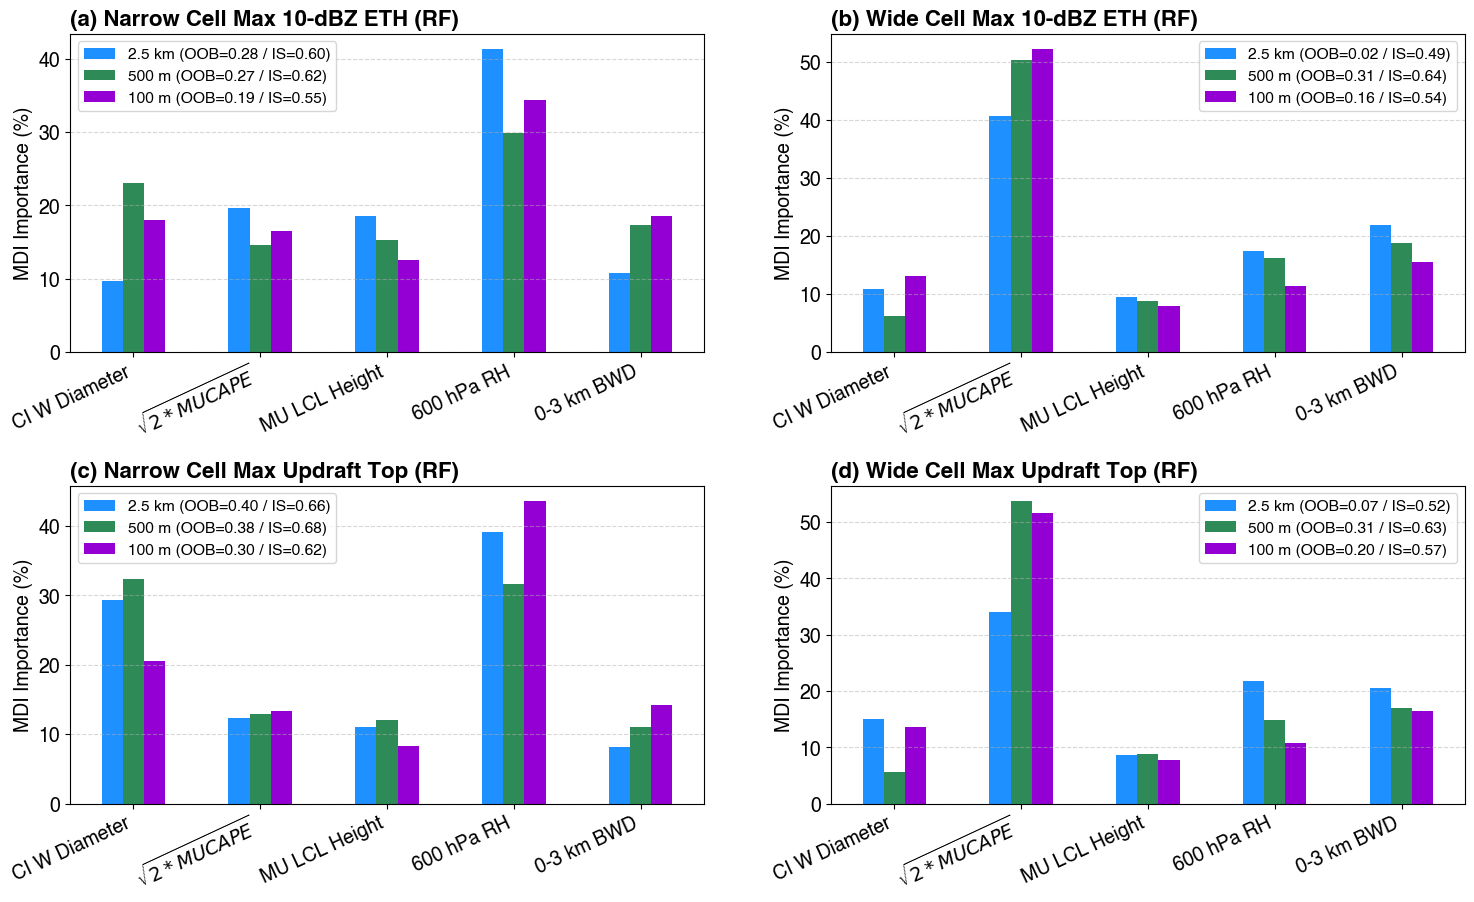

In [45]:
# Plot MDI importances — minimal set
importance_data = [
    [[rf_narrow_minset_eth_d2.feature_importances_, rf_narrow_minset_eth_d3.feature_importances_, rf_narrow_minset_eth_d4.feature_importances_],
    [rf_wide_minset_eth_d2.feature_importances_, rf_wide_minset_eth_d3.feature_importances_, rf_wide_minset_eth_d4.feature_importances_]],
    [[rf_narrow_minset_wtop_d2.feature_importances_, rf_narrow_minset_wtop_d3.feature_importances_, rf_narrow_minset_wtop_d4.feature_importances_],
    [rf_wide_minset_wtop_d2.feature_importances_, rf_wide_minset_wtop_d3.feature_importances_, rf_wide_minset_wtop_d4.feature_importances_]],
]
r2_oob_data = [
    [[r2oob_narrow_minset_eth_d2, r2oob_narrow_minset_eth_d3, r2oob_narrow_minset_eth_d4],
    [r2oob_wide_minset_eth_d2, r2oob_wide_minset_eth_d3, r2oob_wide_minset_eth_d4]],
    [[r2oob_narrow_minset_wtop_d2, r2oob_narrow_minset_wtop_d3, r2oob_narrow_minset_wtop_d4],
    [r2oob_wide_minset_wtop_d2, r2oob_wide_minset_wtop_d3, r2oob_wide_minset_wtop_d4]],
]
r2_insample_data = [
    [[r2in_narrow_minset_eth_d2, r2in_narrow_minset_eth_d3, r2in_narrow_minset_eth_d4],
    [r2in_wide_minset_eth_d2, r2in_wide_minset_eth_d3, r2in_wide_minset_eth_d4]],
    [[r2in_narrow_minset_wtop_d2, r2in_narrow_minset_wtop_d3, r2in_narrow_minset_wtop_d4],
    [r2in_wide_minset_wtop_d2, r2in_wide_minset_wtop_d3, r2in_wide_minset_wtop_d4]],
]
titles = [
    ['(a) Narrow Cell Max 10-dBZ ETH (RF)', '(b) Wide Cell Max 10-dBZ ETH (RF)'],
    ['(c) Narrow Cell Max Updraft Top (RF)', '(d) Wide Cell Max Updraft Top (RF)'],
]
figname = f"{figdir}RF_MDI_Importance_MinSet.png"
fig = plot_2x2_rf_importance(2, 2, importance_data, r2_oob_data, titles, predictors_minset,
    r2_insample_data=r2_insample_data,
    figsize=(18, 10), fontsize=14, xtick_rot=25, hspace=0.42, wspace=0.2, figname=figname)

In [46]:
# # Plot MDI importances — CI-Max W Diameter set
# importance_data = [
#     [[rf_narrow_CIWdiam_eth_d2.feature_importances_, rf_narrow_CIWdiam_eth_d3.feature_importances_, rf_narrow_CIWdiam_eth_d4.feature_importances_],
#     [rf_wide_CIWdiam_eth_d2.feature_importances_, rf_wide_CIWdiam_eth_d3.feature_importances_, rf_wide_CIWdiam_eth_d4.feature_importances_]],
#     [[rf_narrow_CIWdiam_wtop_d2.feature_importances_, rf_narrow_CIWdiam_wtop_d3.feature_importances_, rf_narrow_CIWdiam_wtop_d4.feature_importances_],
#     [rf_wide_CIWdiam_wtop_d2.feature_importances_, rf_wide_CIWdiam_wtop_d3.feature_importances_, rf_wide_CIWdiam_wtop_d4.feature_importances_]],
# ]
# r2_oob_data = [
#     [[r2oob_narrow_CIWdiam_eth_d2, r2oob_narrow_CIWdiam_eth_d3, r2oob_narrow_CIWdiam_eth_d4],
#     [r2oob_wide_CIWdiam_eth_d2, r2oob_wide_CIWdiam_eth_d3, r2oob_wide_CIWdiam_eth_d4]],
#     [[r2oob_narrow_CIWdiam_wtop_d2, r2oob_narrow_CIWdiam_wtop_d3, r2oob_narrow_CIWdiam_wtop_d4],
#     [r2oob_wide_CIWdiam_wtop_d2, r2oob_wide_CIWdiam_wtop_d3, r2oob_wide_CIWdiam_wtop_d4]],
# ]
# r2_insample_data = [
#     [[r2in_narrow_CIWdiam_eth_d2, r2in_narrow_CIWdiam_eth_d3, r2in_narrow_CIWdiam_eth_d4],
#     [r2in_wide_CIWdiam_eth_d2, r2in_wide_CIWdiam_eth_d3, r2in_wide_CIWdiam_eth_d4]],
#     [[r2in_narrow_CIWdiam_wtop_d2, r2in_narrow_CIWdiam_wtop_d3, r2in_narrow_CIWdiam_wtop_d4],
#     [r2in_wide_CIWdiam_wtop_d2, r2in_wide_CIWdiam_wtop_d3, r2in_wide_CIWdiam_wtop_d4]],
# ]
# titles = [
#     ['(a) Narrow Cell Max 10-dBZ ETH (RF)', '(b) Wide Cell Max 10-dBZ ETH (RF)'],
#     ['(c) Narrow Cell Max Updraft Top (RF)', '(d) Wide Cell Max Updraft Top (RF)'],
# ]
# figname = f"{figdir}RF_MDI_Importance_CI-MaxWdiam.png"
# fig = plot_2x2_rf_importance(2, 2, importance_data, r2_oob_data, titles, predictors_CIWdiam,
#     r2_insample_data=r2_insample_data,
#     figsize=(18, 10), fontsize=14, xtick_rot=25, hspace=0.42, wspace=0.2, figname=figname)

Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_MDI_Importance_AllSet.png


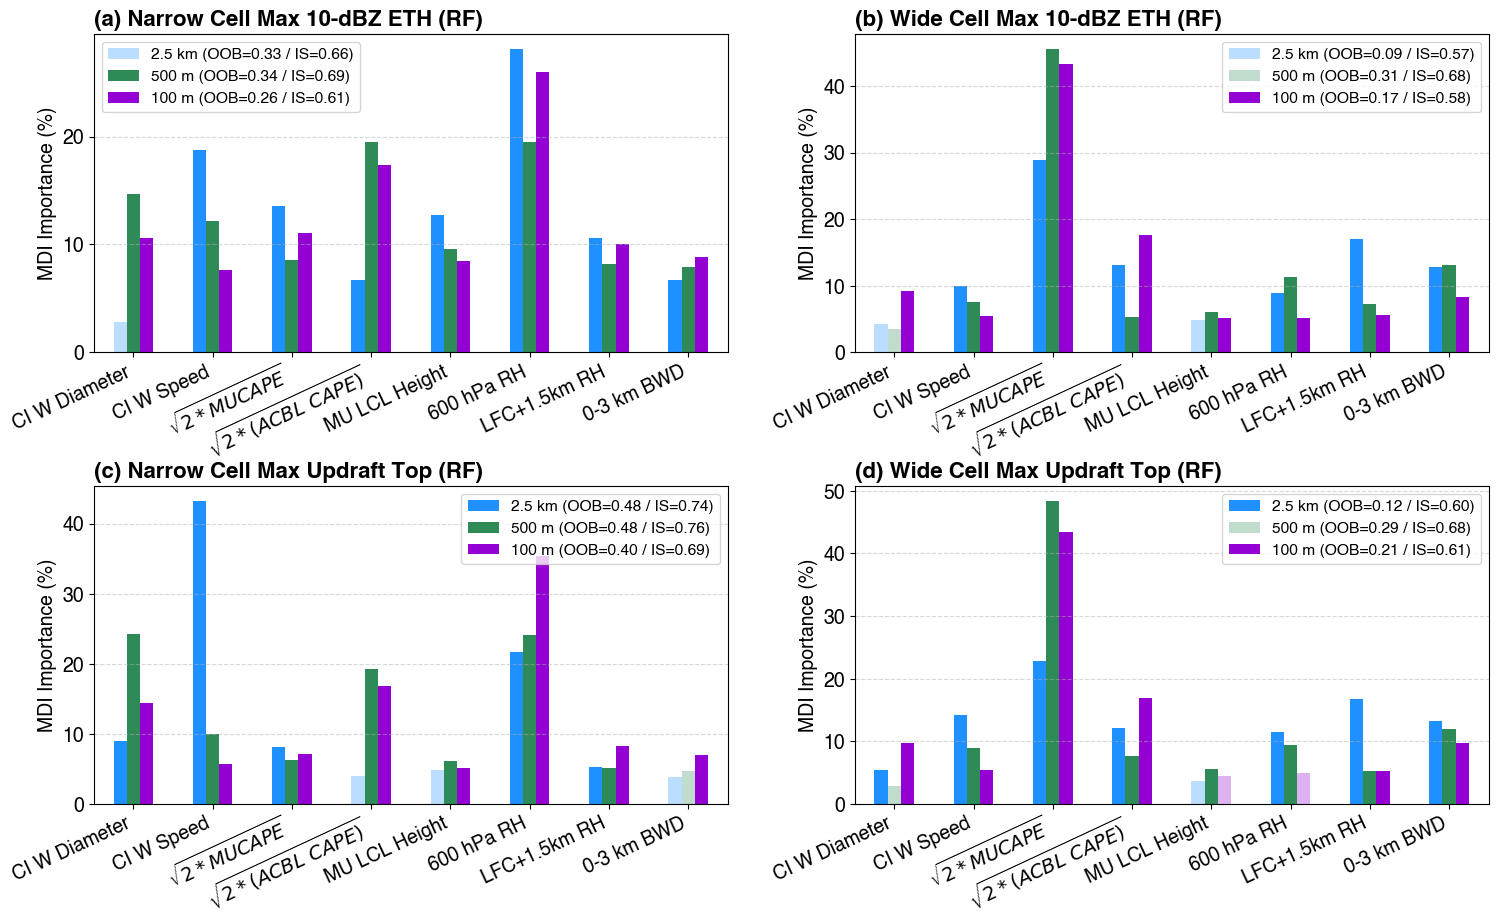

In [47]:
# Plot MDI importances — all predictor set
importance_data = [
    [[rf_narrow_all_eth_d2.feature_importances_, rf_narrow_all_eth_d3.feature_importances_, rf_narrow_all_eth_d4.feature_importances_],
    [rf_wide_all_eth_d2.feature_importances_, rf_wide_all_eth_d3.feature_importances_, rf_wide_all_eth_d4.feature_importances_]],
    [[rf_narrow_all_wtop_d2.feature_importances_, rf_narrow_all_wtop_d3.feature_importances_, rf_narrow_all_wtop_d4.feature_importances_],
    [rf_wide_all_wtop_d2.feature_importances_, rf_wide_all_wtop_d3.feature_importances_, rf_wide_all_wtop_d4.feature_importances_]],
]
r2_oob_data = [
    [[r2oob_narrow_all_eth_d2, r2oob_narrow_all_eth_d3, r2oob_narrow_all_eth_d4],
    [r2oob_wide_all_eth_d2, r2oob_wide_all_eth_d3, r2oob_wide_all_eth_d4]],
    [[r2oob_narrow_all_wtop_d2, r2oob_narrow_all_wtop_d3, r2oob_narrow_all_wtop_d4],
    [r2oob_wide_all_wtop_d2, r2oob_wide_all_wtop_d3, r2oob_wide_all_wtop_d4]],
]
r2_insample_data = [
    [[r2in_narrow_all_eth_d2, r2in_narrow_all_eth_d3, r2in_narrow_all_eth_d4],
    [r2in_wide_all_eth_d2, r2in_wide_all_eth_d3, r2in_wide_all_eth_d4]],
    [[r2in_narrow_all_wtop_d2, r2in_narrow_all_wtop_d3, r2in_narrow_all_wtop_d4],
    [r2in_wide_all_wtop_d2, r2in_wide_all_wtop_d3, r2in_wide_all_wtop_d4]],
]
titles = [
    ['(a) Narrow Cell Max 10-dBZ ETH (RF)', '(b) Wide Cell Max 10-dBZ ETH (RF)'],
    ['(c) Narrow Cell Max Updraft Top (RF)', '(d) Wide Cell Max Updraft Top (RF)'],
]
figname = f"{figdir}RF_MDI_Importance_AllSet.png"
fig = plot_2x2_rf_importance(2, 2, importance_data, r2_oob_data, titles, predictors_all,
    r2_insample_data=r2_insample_data,
    figsize=(18, 10), fontsize=14, xtick_rot=25, hspace=0.42, wspace=0.2, figname=figname)

## SHAP Values: Signed Predictor Contributions

SHAP (SHapley Additive exPlanations) decomposes each RF prediction into additive contributions from each predictor, with a sign indicating the direction of the effect.

The mean SHAP value across all samples gives the average signed contribution of each predictor. Bootstrap 95% confidence intervals (1000 resamples) of the mean SHAP are computed to assess statistical consistency:
- **If the bootstrap CI does not cross zero**, the predictor's directional effect is statistically consistent across samples — analogous to the MLR standardized coefficient CI not crossing zero.
- **If the CI crosses zero**, the sign of the contribution is not robust and should be interpreted cautiously.

In [48]:
def compute_shap_stats(rf_model, X_clean, n_bootstrap=1000, random_state=42):
    """
    Compute mean SHAP values and bootstrap 95% CI for each predictor.

    Parameters
    ----------
    rf_model : fitted RandomForestRegressor
    X_clean : ndarray, shape (n_samples, n_predictors)
        Predictor matrix (same as used for training, without NaNs).
    n_bootstrap : int
        Number of bootstrap resamples for CI estimation.
    random_state : int

    Returns
    -------
    mean_shap : ndarray, shape (n_predictors,)
        Mean SHAP value per predictor (signed).
    ci_lower : ndarray, shape (n_predictors,)
        2.5th percentile of bootstrap distribution of mean SHAP.
    ci_upper : ndarray, shape (n_predictors,)
        97.5th percentile of bootstrap distribution of mean SHAP.
    """
    explainer = shap.TreeExplainer(rf_model)
    sv = explainer(X_clean)          # shap 0.51+ Explanation object
    shap_values = sv.values          # (n_samples, n_predictors)
    mean_shap = np.mean(shap_values, axis=0)

    rng = np.random.default_rng(random_state)
    n = len(shap_values)
    boot_means = np.array([
        np.mean(shap_values[rng.integers(0, n, n)], axis=0)
        for _ in range(n_bootstrap)
    ])
    ci_lower = np.percentile(boot_means, 2.5, axis=0)
    ci_upper = np.percentile(boot_means, 97.5, axis=0)
    return mean_shap, ci_lower, ci_upper

In [49]:
def plot_shap_errbar(predictors, shap_n_dict, ci_n_dict, shap_w_dict, ci_w_dict,
                     ylims=None, yticks=None, ylabel='Mean SHAP Value (km)',
                     suptitle=None, figname=None, figsize=(14, 5),
                     xtick2_rot=30, xtick2_ha='center',
                     fontsize=14, markersize=8, errbar_lw=2, dpi=300):
    """
    Plot mean SHAP values with bootstrap 95% CI bars for narrow and wide cells.

    Analogous to plot_coef_errbar from the MLR notebook: narrow cells use filled
    diamond markers, wide cells use open diamonds. D2/D3/D4 are shown as separate
    markers offset within each narrow/wide group for each predictor.

    Parameters
    ----------
    predictors : list of str
        Predictor names (used for secondary x-axis labels).
    shap_n_dict : dict  {d2, d3, d4} -> mean_shap array (n_predictors,)
        Mean SHAP values for narrow cells per domain.
    ci_n_dict : dict  {d2, d3, d4} -> [ci_lower, ci_upper] arrays (n_predictors,)
        Bootstrap 95% CI bounds for narrow cells.
    shap_w_dict : dict  {d2, d3, d4} -> mean_shap array
    ci_w_dict : dict  {d2, d3, d4} -> [ci_lower, ci_upper]
    """
    lcolors = {'d2': 'dodgerblue', 'd3': 'seagreen', 'd4': 'darkviolet'}
    domain_labels_long = {'d2': 'D2 (2.5 km)', 'd3': 'D3 (500 m)', 'd4': 'D4 (100 m)'}
    offsets = {'d2': -0.2, 'd3': 0.0, 'd4': 0.2}
    n_preds = len(predictors)

    # x positions: predictor k -> narrow center = k*3+1, wide center = k*3+2
    def get_x_positions(center_base, domain):
        return np.array([center_base + k * 3 + offsets[domain] for k in range(n_preds)])

    mpl.rcParams['font.size'] = fontsize

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    for dom in ['d2', 'd3', 'd4']:
        x_n = get_x_positions(1, dom)
        x_w = get_x_positions(2, dom)

        # Narrow: filled diamonds
        ax.plot(x_n, shap_n_dict[dom], 'D', markersize=markersize,
                color=lcolors[dom], label=domain_labels_long[dom], zorder=5)
        for ii in range(n_preds):
            ax.plot([x_n[ii], x_n[ii]],
                    [ci_n_dict[dom][0][ii], ci_n_dict[dom][1][ii]],
                    lw=errbar_lw, color=lcolors[dom], zorder=4)

        # Wide: open diamonds (mfc='none')
        ax.plot(x_w, shap_w_dict[dom], 'D', markersize=markersize,
                color=lcolors[dom], mfc='none', zorder=5)
        for ii in range(n_preds):
            ax.plot([x_w[ii], x_w[ii]],
                    [ci_w_dict[dom][0][ii], ci_w_dict[dom][1][ii]],
                    lw=errbar_lw, color=lcolors[dom], zorder=4)

    # Zero reference line
    ax.axhline(y=0, color='k', lw=1, zorder=3)

    # Vertical gray dividers between predictor groups
    for k in range(n_preds - 1):
        ax.axvline(x=k * 3 + 2.7, color='gray', ls='--', lw=0.8, zorder=2)

    # N/W labels inside the first predictor group
    # ax.text(1, ax.get_ylim()[0] if ylims is None else ylims[0],
    #         'N', ha='center', va='bottom', fontsize=fontsize * 0.8, color='gray')
    # ax.text(2, ax.get_ylim()[0] if ylims is None else ylims[0],
    #         'W', ha='center', va='bottom', fontsize=fontsize * 0.8, color='gray')

    # Secondary x-axis at top: predictor names
    secax = ax.secondary_xaxis('top')
    xlabel_pos = [k * 3 + 1.5 for k in range(n_preds)]
    secax.set_xticks(xlabel_pos)
    secax.set_xticklabels(predictors, rotation=xtick2_rot, ha=xtick2_ha, fontsize=fontsize * 0.85)
    secax.tick_params(length=0)

    # Primary x-axis: N/W ticks below each predictor group
    n_ticks = [k * 3 + 1 for k in range(n_preds)]
    w_ticks = [k * 3 + 2 for k in range(n_preds)]
    all_ticks = sorted(n_ticks + w_ticks)
    all_labels = []
    for t in all_ticks:
        if t in n_ticks:
            all_labels.append('Narrow')
        else:
            all_labels.append('Wide')
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(all_labels, fontsize=fontsize * 0.8)

    xlims = (-0.5, n_preds * 3 + 0.5)
    ax.set_xlim(xlims)
    if ylims is not None:
        ax.set_ylim(ylims)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.grid(ls=':', axis='y', alpha=0.5)
    ax.legend(loc='best', fontsize=fontsize * 0.85)

    if suptitle:
        fig.suptitle(suptitle, fontsize=fontsize + 4, fontweight='bold', y=1.02)

    fig.tight_layout()
    if figname is not None:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        print(f'Saved: {figname}')
    return fig

### Compute SHAP statistics — minimal set (ETH + WTop)

In [50]:
print("Computing SHAP stats (minset ETH)...")
(mean_shap_narrow_minset_eth_d2, ci_lo_narrow_minset_eth_d2, ci_hi_narrow_minset_eth_d2) = \
    compute_shap_stats(rf_narrow_minset_eth_d2, X_narrow_minset_eth_d2)
(mean_shap_narrow_minset_eth_d3, ci_lo_narrow_minset_eth_d3, ci_hi_narrow_minset_eth_d3) = \
    compute_shap_stats(rf_narrow_minset_eth_d3, X_narrow_minset_eth_d3)
(mean_shap_narrow_minset_eth_d4, ci_lo_narrow_minset_eth_d4, ci_hi_narrow_minset_eth_d4) = \
    compute_shap_stats(rf_narrow_minset_eth_d4, X_narrow_minset_eth_d4)

(mean_shap_wide_minset_eth_d2, ci_lo_wide_minset_eth_d2, ci_hi_wide_minset_eth_d2) = \
    compute_shap_stats(rf_wide_minset_eth_d2, X_wide_minset_eth_d2)
(mean_shap_wide_minset_eth_d3, ci_lo_wide_minset_eth_d3, ci_hi_wide_minset_eth_d3) = \
    compute_shap_stats(rf_wide_minset_eth_d3, X_wide_minset_eth_d3)
(mean_shap_wide_minset_eth_d4, ci_lo_wide_minset_eth_d4, ci_hi_wide_minset_eth_d4) = \
    compute_shap_stats(rf_wide_minset_eth_d4, X_wide_minset_eth_d4)
print("  ETH done")

print("Computing SHAP stats (minset WTop)...")
(mean_shap_narrow_minset_wtop_d2, ci_lo_narrow_minset_wtop_d2, ci_hi_narrow_minset_wtop_d2) = \
    compute_shap_stats(rf_narrow_minset_wtop_d2, X_narrow_minset_wtop_d2)
(mean_shap_narrow_minset_wtop_d3, ci_lo_narrow_minset_wtop_d3, ci_hi_narrow_minset_wtop_d3) = \
    compute_shap_stats(rf_narrow_minset_wtop_d3, X_narrow_minset_wtop_d3)
(mean_shap_narrow_minset_wtop_d4, ci_lo_narrow_minset_wtop_d4, ci_hi_narrow_minset_wtop_d4) = \
    compute_shap_stats(rf_narrow_minset_wtop_d4, X_narrow_minset_wtop_d4)

(mean_shap_wide_minset_wtop_d2, ci_lo_wide_minset_wtop_d2, ci_hi_wide_minset_wtop_d2) = \
    compute_shap_stats(rf_wide_minset_wtop_d2, X_wide_minset_wtop_d2)
(mean_shap_wide_minset_wtop_d3, ci_lo_wide_minset_wtop_d3, ci_hi_wide_minset_wtop_d3) = \
    compute_shap_stats(rf_wide_minset_wtop_d3, X_wide_minset_wtop_d3)
(mean_shap_wide_minset_wtop_d4, ci_lo_wide_minset_wtop_d4, ci_hi_wide_minset_wtop_d4) = \
    compute_shap_stats(rf_wide_minset_wtop_d4, X_wide_minset_wtop_d4)
print("  WTop done")

Computing SHAP stats (minset ETH)...
  ETH done
Computing SHAP stats (minset WTop)...
  WTop done


### Plot SHAP errbar — minimal set, Max 10-dBZ ETH

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_SHAP_ETH_MinSet.png
Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_SHAP_ETH_MinSet.png


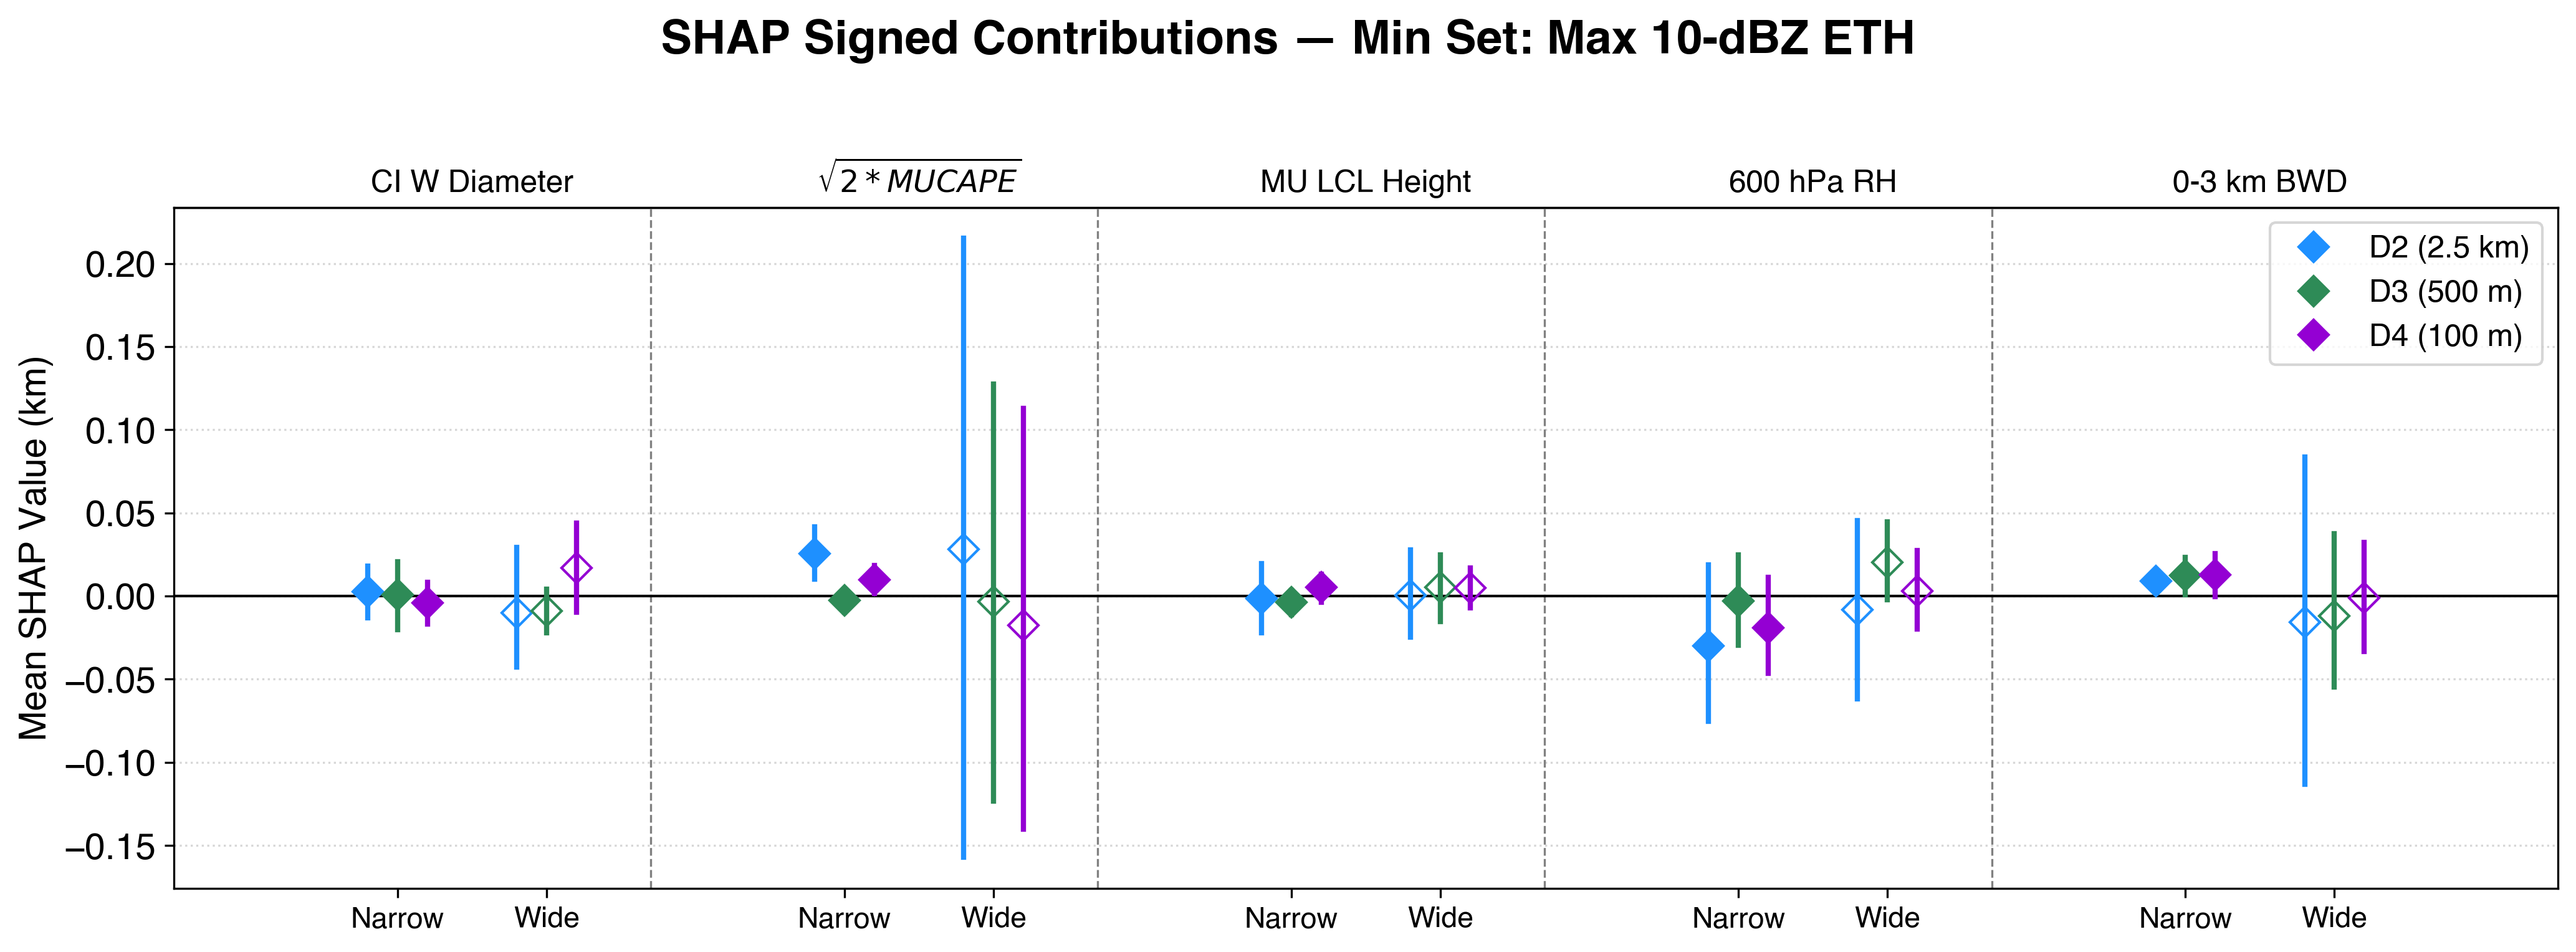

In [51]:
shap_n_eth = {
    'd2': mean_shap_narrow_minset_eth_d2,
    'd3': mean_shap_narrow_minset_eth_d3,
    'd4': mean_shap_narrow_minset_eth_d4,
}
ci_n_eth = {
    'd2': [ci_lo_narrow_minset_eth_d2, ci_hi_narrow_minset_eth_d2],
    'd3': [ci_lo_narrow_minset_eth_d3, ci_hi_narrow_minset_eth_d3],
    'd4': [ci_lo_narrow_minset_eth_d4, ci_hi_narrow_minset_eth_d4],
}
shap_w_eth = {
    'd2': mean_shap_wide_minset_eth_d2,
    'd3': mean_shap_wide_minset_eth_d3,
    'd4': mean_shap_wide_minset_eth_d4,
}
ci_w_eth = {
    'd2': [ci_lo_wide_minset_eth_d2, ci_hi_wide_minset_eth_d2],
    'd3': [ci_lo_wide_minset_eth_d3, ci_hi_wide_minset_eth_d3],
    'd4': [ci_lo_wide_minset_eth_d4, ci_hi_wide_minset_eth_d4],
}

figname = f"{figdir}RF_SHAP_ETH_MinSet.png"
print(figname)
fig = plot_shap_errbar(
    predictors_minset,
    shap_n_eth, ci_n_eth,
    shap_w_eth, ci_w_eth,
    ylabel='Mean SHAP Value (km)',
    suptitle='SHAP Signed Contributions — Min Set: Max 10-dBZ ETH',
    xtick2_rot=0, xtick2_ha='center',
    figsize=(14, 5), fontsize=14, markersize=8, errbar_lw=2, dpi=300,
    figname=figname,
)

### Plot SHAP errbar — minimal set, Max Updraft Top

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_SHAP_WTop_MinSet.png
Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_SHAP_WTop_MinSet.png


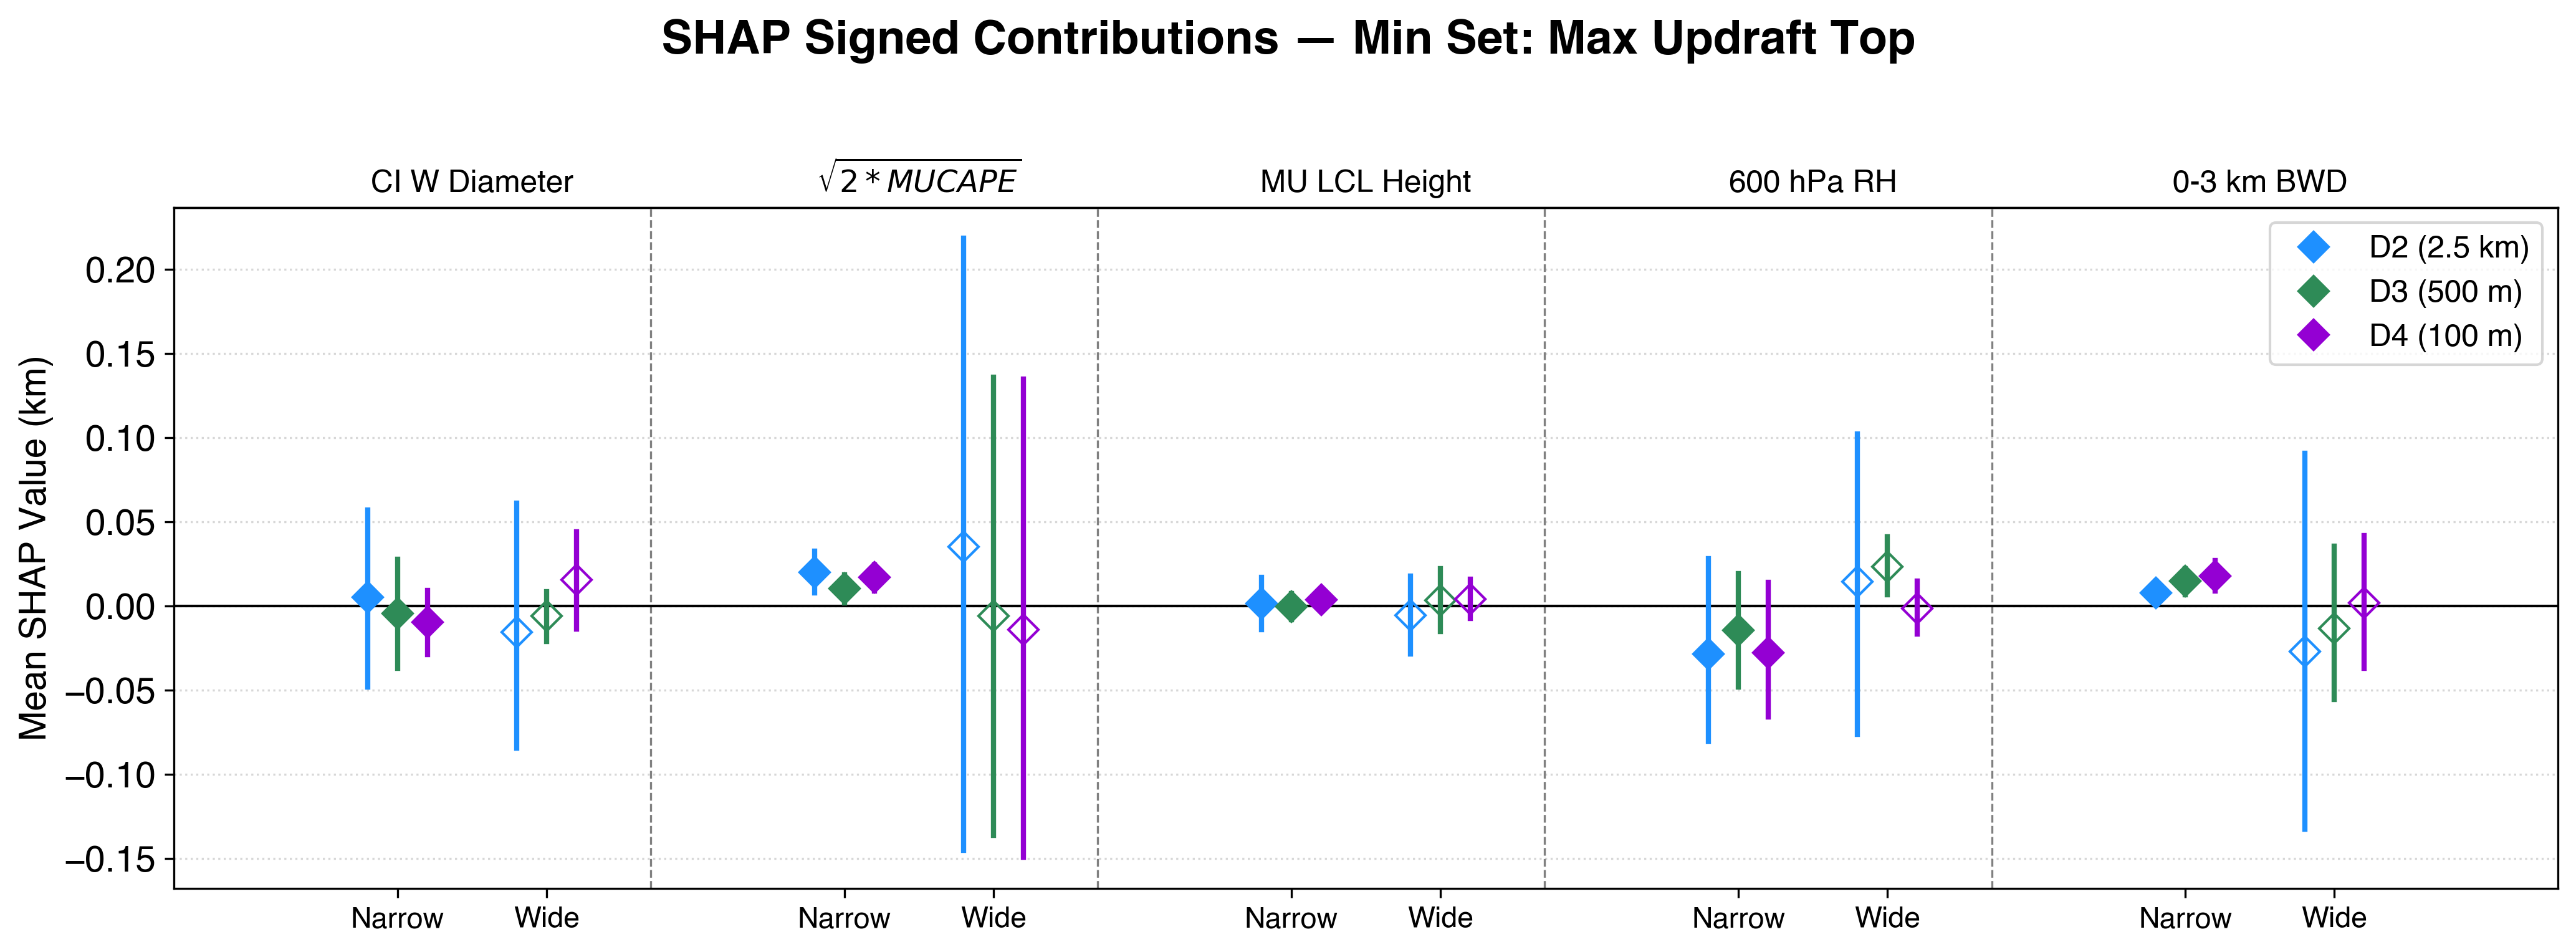

In [52]:
shap_n_wtop = {
    'd2': mean_shap_narrow_minset_wtop_d2,
    'd3': mean_shap_narrow_minset_wtop_d3,
    'd4': mean_shap_narrow_minset_wtop_d4,
}
ci_n_wtop = {
    'd2': [ci_lo_narrow_minset_wtop_d2, ci_hi_narrow_minset_wtop_d2],
    'd3': [ci_lo_narrow_minset_wtop_d3, ci_hi_narrow_minset_wtop_d3],
    'd4': [ci_lo_narrow_minset_wtop_d4, ci_hi_narrow_minset_wtop_d4],
}
shap_w_wtop = {
    'd2': mean_shap_wide_minset_wtop_d2,
    'd3': mean_shap_wide_minset_wtop_d3,
    'd4': mean_shap_wide_minset_wtop_d4,
}
ci_w_wtop = {
    'd2': [ci_lo_wide_minset_wtop_d2, ci_hi_wide_minset_wtop_d2],
    'd3': [ci_lo_wide_minset_wtop_d3, ci_hi_wide_minset_wtop_d3],
    'd4': [ci_lo_wide_minset_wtop_d4, ci_hi_wide_minset_wtop_d4],
}

figname = f"{figdir}RF_SHAP_WTop_MinSet.png"
print(figname)
fig = plot_shap_errbar(
    predictors_minset,
    shap_n_wtop, ci_n_wtop,
    shap_w_wtop, ci_w_wtop,
    ylabel='Mean SHAP Value (km)',
    suptitle='SHAP Signed Contributions — Min Set: Max Updraft Top',
    xtick2_rot=0, xtick2_ha='center',
    figsize=(14, 5), fontsize=14, markersize=8, errbar_lw=2, dpi=300,
    figname=figname,
)

### Compute SHAP statistics — all predictor set (ETH + WTop)

In [53]:
print("Computing SHAP stats (all-set ETH)...")
(mean_shap_narrow_all_eth_d2, ci_lo_narrow_all_eth_d2, ci_hi_narrow_all_eth_d2) = \
    compute_shap_stats(rf_narrow_all_eth_d2, X_narrow_all_eth_d2)
(mean_shap_narrow_all_eth_d3, ci_lo_narrow_all_eth_d3, ci_hi_narrow_all_eth_d3) = \
    compute_shap_stats(rf_narrow_all_eth_d3, X_narrow_all_eth_d3)
(mean_shap_narrow_all_eth_d4, ci_lo_narrow_all_eth_d4, ci_hi_narrow_all_eth_d4) = \
    compute_shap_stats(rf_narrow_all_eth_d4, X_narrow_all_eth_d4)

(mean_shap_wide_all_eth_d2, ci_lo_wide_all_eth_d2, ci_hi_wide_all_eth_d2) = \
    compute_shap_stats(rf_wide_all_eth_d2, X_wide_all_eth_d2)
(mean_shap_wide_all_eth_d3, ci_lo_wide_all_eth_d3, ci_hi_wide_all_eth_d3) = \
    compute_shap_stats(rf_wide_all_eth_d3, X_wide_all_eth_d3)
(mean_shap_wide_all_eth_d4, ci_lo_wide_all_eth_d4, ci_hi_wide_all_eth_d4) = \
    compute_shap_stats(rf_wide_all_eth_d4, X_wide_all_eth_d4)
print("  ETH done")

print("Computing SHAP stats (all-set WTop)...")
(mean_shap_narrow_all_wtop_d2, ci_lo_narrow_all_wtop_d2, ci_hi_narrow_all_wtop_d2) = \
    compute_shap_stats(rf_narrow_all_wtop_d2, X_narrow_all_wtop_d2)
(mean_shap_narrow_all_wtop_d3, ci_lo_narrow_all_wtop_d3, ci_hi_narrow_all_wtop_d3) = \
    compute_shap_stats(rf_narrow_all_wtop_d3, X_narrow_all_wtop_d3)
(mean_shap_narrow_all_wtop_d4, ci_lo_narrow_all_wtop_d4, ci_hi_narrow_all_wtop_d4) = \
    compute_shap_stats(rf_narrow_all_wtop_d4, X_narrow_all_wtop_d4)

(mean_shap_wide_all_wtop_d2, ci_lo_wide_all_wtop_d2, ci_hi_wide_all_wtop_d2) = \
    compute_shap_stats(rf_wide_all_wtop_d2, X_wide_all_wtop_d2)
(mean_shap_wide_all_wtop_d3, ci_lo_wide_all_wtop_d3, ci_hi_wide_all_wtop_d3) = \
    compute_shap_stats(rf_wide_all_wtop_d3, X_wide_all_wtop_d3)
(mean_shap_wide_all_wtop_d4, ci_lo_wide_all_wtop_d4, ci_hi_wide_all_wtop_d4) = \
    compute_shap_stats(rf_wide_all_wtop_d4, X_wide_all_wtop_d4)
print("  WTop done")

Computing SHAP stats (all-set ETH)...
  ETH done
Computing SHAP stats (all-set WTop)...
  WTop done


### Plot SHAP errbar — all predictor set, Max 10-dBZ ETH

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_SHAP_ETH_AllSet.png
Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_SHAP_ETH_AllSet.png


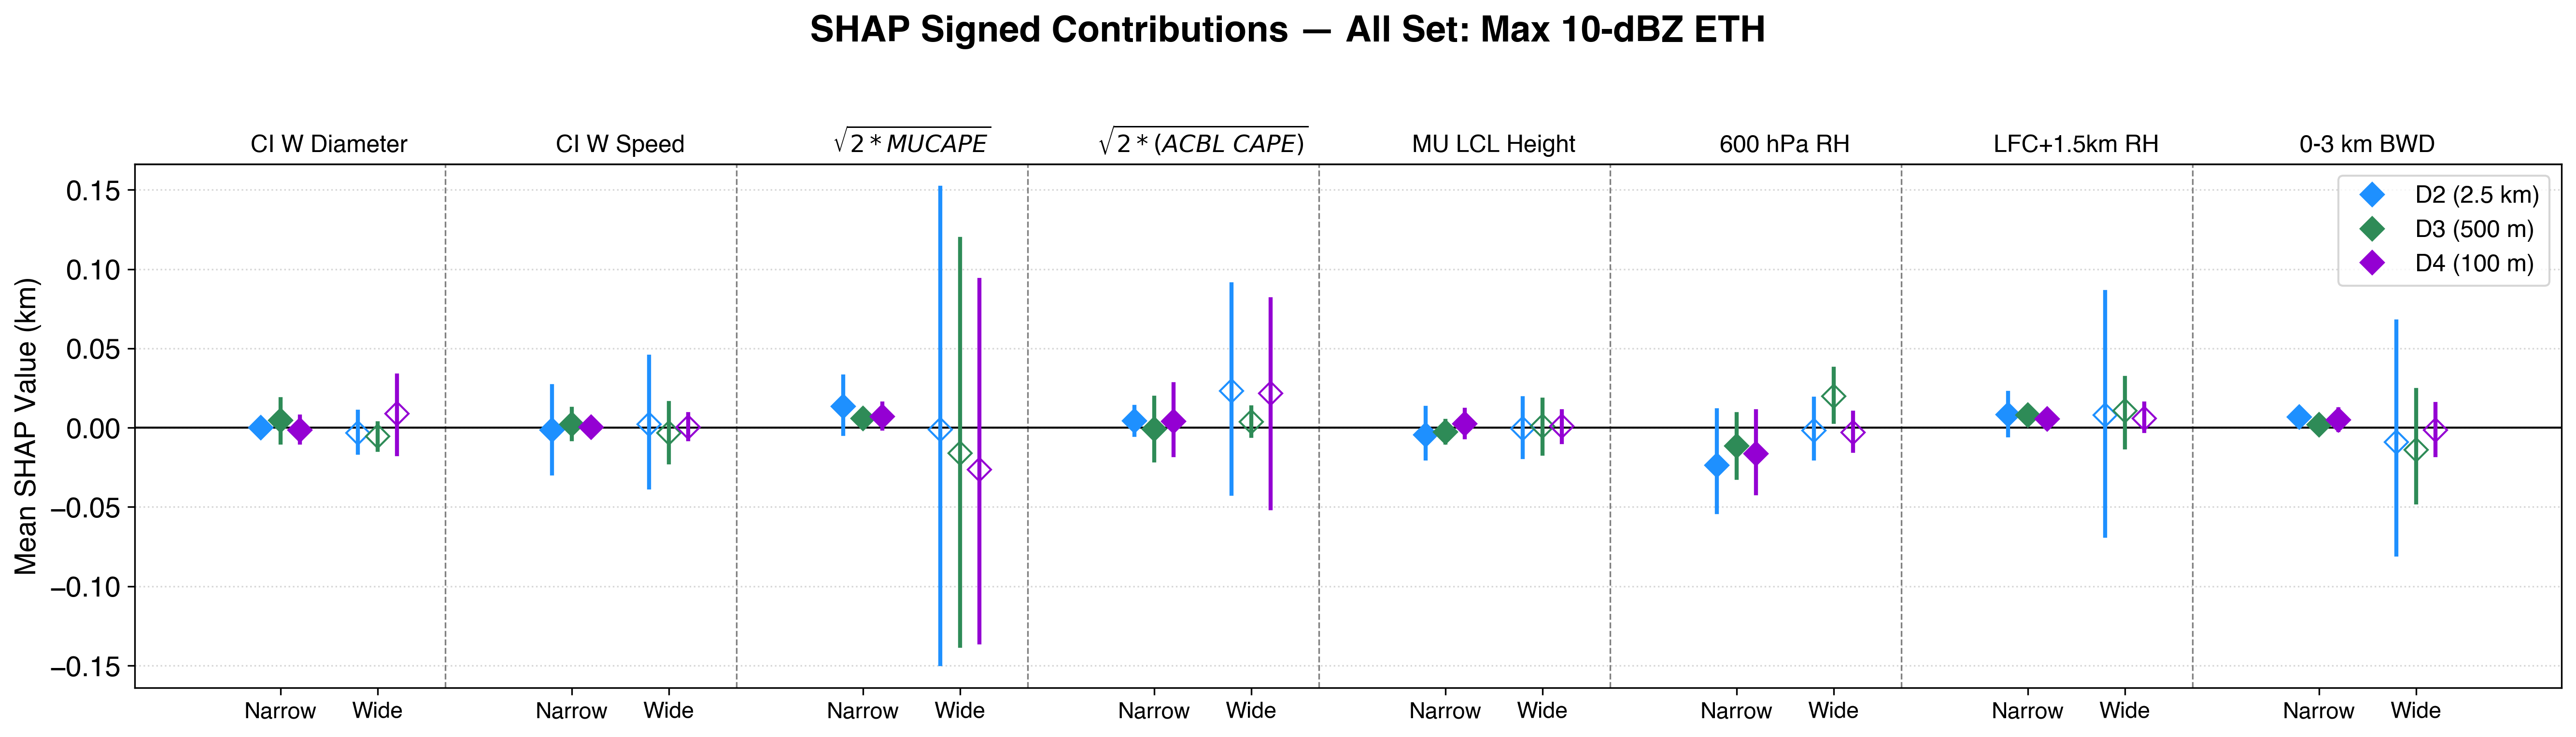

In [54]:
shap_n_all_eth = {
    'd2': mean_shap_narrow_all_eth_d2,
    'd3': mean_shap_narrow_all_eth_d3,
    'd4': mean_shap_narrow_all_eth_d4,
}
ci_n_all_eth = {
    'd2': [ci_lo_narrow_all_eth_d2, ci_hi_narrow_all_eth_d2],
    'd3': [ci_lo_narrow_all_eth_d3, ci_hi_narrow_all_eth_d3],
    'd4': [ci_lo_narrow_all_eth_d4, ci_hi_narrow_all_eth_d4],
}
shap_w_all_eth = {
    'd2': mean_shap_wide_all_eth_d2,
    'd3': mean_shap_wide_all_eth_d3,
    'd4': mean_shap_wide_all_eth_d4,
}
ci_w_all_eth = {
    'd2': [ci_lo_wide_all_eth_d2, ci_hi_wide_all_eth_d2],
    'd3': [ci_lo_wide_all_eth_d3, ci_hi_wide_all_eth_d3],
    'd4': [ci_lo_wide_all_eth_d4, ci_hi_wide_all_eth_d4],
}

figname = f"{figdir}RF_SHAP_ETH_AllSet.png"
print(figname)
fig = plot_shap_errbar(
    predictors_all,
    shap_n_all_eth, ci_n_all_eth,
    shap_w_all_eth, ci_w_all_eth,
    ylabel='Mean SHAP Value (km)',
    suptitle='SHAP Signed Contributions — All Set: Max 10-dBZ ETH',
    xtick2_rot=0, xtick2_ha='center',
    figsize=(18, 5), fontsize=14, markersize=8, errbar_lw=2, dpi=300,
    figname=figname,
)

### Plot SHAP errbar — all predictor set, Max Updraft Top

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_SHAP_WTop_AllSet.png
Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_SHAP_WTop_AllSet.png


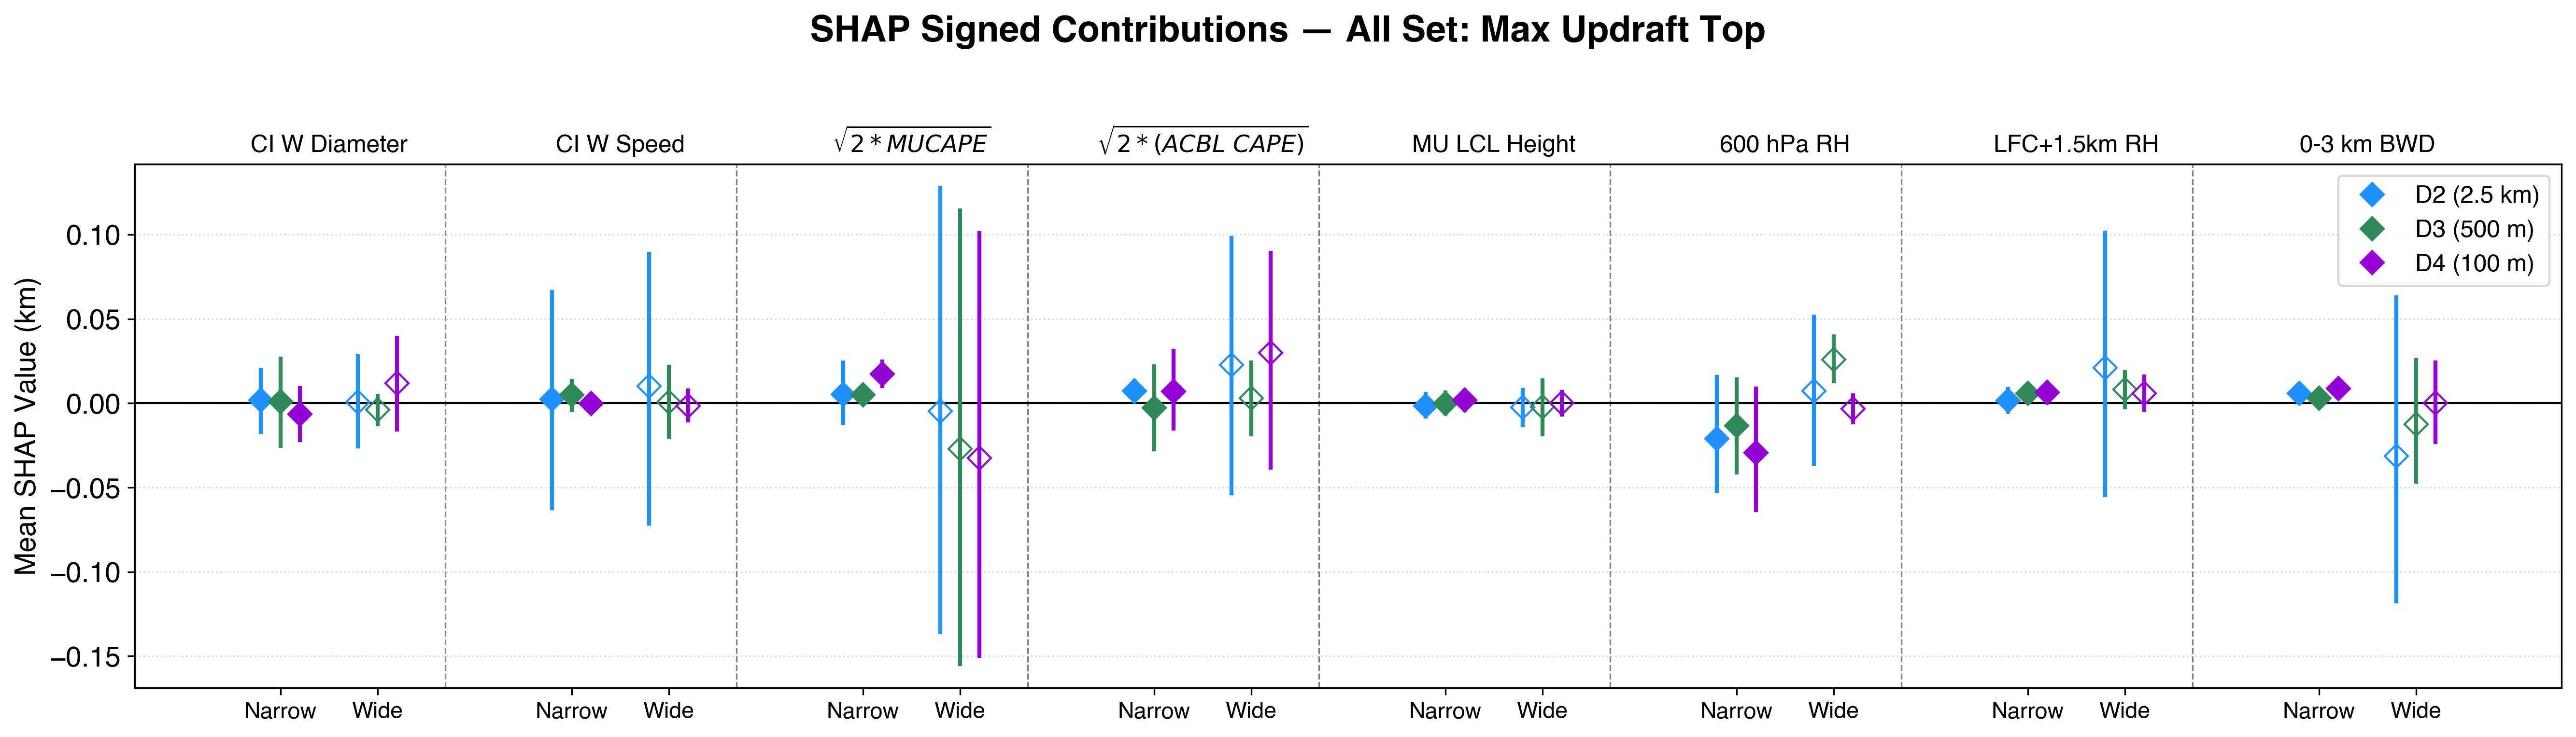

In [55]:
shap_n_all_wtop = {
    'd2': mean_shap_narrow_all_wtop_d2,
    'd3': mean_shap_narrow_all_wtop_d3,
    'd4': mean_shap_narrow_all_wtop_d4,
}
ci_n_all_wtop = {
    'd2': [ci_lo_narrow_all_wtop_d2, ci_hi_narrow_all_wtop_d2],
    'd3': [ci_lo_narrow_all_wtop_d3, ci_hi_narrow_all_wtop_d3],
    'd4': [ci_lo_narrow_all_wtop_d4, ci_hi_narrow_all_wtop_d4],
}
shap_w_all_wtop = {
    'd2': mean_shap_wide_all_wtop_d2,
    'd3': mean_shap_wide_all_wtop_d3,
    'd4': mean_shap_wide_all_wtop_d4,
}
ci_w_all_wtop = {
    'd2': [ci_lo_wide_all_wtop_d2, ci_hi_wide_all_wtop_d2],
    'd3': [ci_lo_wide_all_wtop_d3, ci_hi_wide_all_wtop_d3],
    'd4': [ci_lo_wide_all_wtop_d4, ci_hi_wide_all_wtop_d4],
}

figname = f"{figdir}RF_SHAP_WTop_AllSet.png"
print(figname)
fig = plot_shap_errbar(
    predictors_all,
    shap_n_all_wtop, ci_n_all_wtop,
    shap_w_all_wtop, ci_w_all_wtop,
    ylabel='Mean SHAP Value (km)',
    suptitle='SHAP Signed Contributions — All Set: Max Updraft Top',
    xtick2_rot=0, xtick2_ha='center',
    figsize=(18, 5), fontsize=14, markersize=8, errbar_lw=2, dpi=300,
    figname=figname,
)

## RF Predicted vs. Actual Values

2D density heatmaps comparing RF-predicted values against actual (observed) values for each domain (D2/D3/D4) and cell type (narrow/wide). A 1-to-1 diagonal line is plotted for reference — tighter clustering around this line indicates better prediction.

In [56]:
def mxn_heatmap(nrow, ncol, x_arr, y_arr, bins_hist=None, bin_range=None,
                cmaps=None, cbar_labels=None, kde_levels=None, kde_colors=None,
                wspace=None, hspace=None, xticks=None, yticks=None,
                vmin=None, vmax=None, xlims=None, ylims=None,
                xlabels=None, ylabels=None, titles=None, suptitle=None,
                fontsize=None, figsize=None, figname=None, dpi=None):
    """
    Plot an M×N grid of 2D density heatmaps (RF predicted vs. actual).

    Parameters
    ----------
    x_arr : nested list [nrow][ncol]
        Actual (observed) values per panel.
    y_arr : nested list [nrow][ncol]
        RF-predicted values per panel.
    bins_hist : nested list [nrow][ncol]
        Bin arrays for sns.histplot (can be the same array repeated).
        Each element can be a 1D array (same bins for both axes) or a
        tuple (bins_x, bins_y).
    bin_range : nested list [nrow][ncol]
        (xmin, xmax) range for each panel's histplot.
    cmaps, cbar_labels, kde_levels, kde_colors, vmin, vmax : nested [nrow][ncol] or scalars
        Visual parameters per panel (or applied uniformly if scalar/single).
    xlims, ylims : nested list [nrow][ncol]  (xmin, xmax) axis limits.
    xlabels, ylabels, titles : nested list [nrow][ncol]
    """
    mpl.rcParams['font.size'] = fontsize

    fig = plt.figure(figsize=figsize, dpi=dpi)

    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpec(nrow, ncol, figure=fig,
                           height_ratios=h_ratios, width_ratios=w_ratios,
                           wspace=wspace, hspace=hspace)

    for row in range(nrow):
        for col in range(ncol):
            # Sub-gridspec: [plot | narrow colorbar]
            gss = gridspec.GridSpecFromSubplotSpec(
                1, 2, subplot_spec=gs[row, col],
                width_ratios=[1, 0.04], wspace=0.02, hspace=0.
            )
            ax  = plt.subplot(gss[0])
            cax = plt.subplot(gss[1])

            xx = x_arr[row][col]
            yy = y_arr[row][col]

            # For bivariate histplot, bins must be a tuple (bins_x, bins_y).
            # Wrap a plain array into a tuple so seaborn doesn't fail on
            # `if not bins` truth-testing of an ndarray.
            raw_bins = bins_hist[row][col]
            if isinstance(raw_bins, np.ndarray):
                bins_for_hist = (raw_bins, raw_bins)
            else:
                bins_for_hist = raw_bins  # already a tuple or int

            # bin_range for bivariate: pass as ((xmin,xmax),(ymin,ymax))
            raw_range = bin_range[row][col]
            if (isinstance(raw_range, (tuple, list)) and len(raw_range) == 2
                    and not isinstance(raw_range[0], (tuple, list))):
                range_for_hist = (raw_range, raw_range)
            else:
                range_for_hist = raw_range

            # 2D histogram
            sns.histplot(
                x=xx, y=yy,
                bins=bins_for_hist,
                binrange=range_for_hist,
                pthresh=0.1,
                cmap=cmaps[row][col],
                cbar=True,
                cbar_kws={'label': cbar_labels[row][col]},
                cbar_ax=cax,
                ax=ax,
                stat='percent',
            )

            # KDE overlay
            try:
                sns.kdeplot(
                    x=xx, y=yy,
                    levels=kde_levels[row][col],
                    color=kde_colors[row][col],
                    linewidths=1,
                    ax=ax,
                )
            except Exception:
                pass  # KDE may fail on small samples; skip gracefully

            # Set axis limits then draw 1-to-1 line
            if xlims is not None:
                ax.set_xlim(xlims[row][col])
            if ylims is not None:
                ax.set_ylim(ylims[row][col])

            xlim = ax.get_xlim()
            ax.plot(xlim, xlim, 'k--', lw=1.2, label='1:1')

            if xticks is not None:
                ax.set_xticks(xticks[row][col])
            if yticks is not None:
                ax.set_yticks(yticks[row][col])

            ax.set_xlabel(xlabels[row][col], fontsize=fontsize)
            ax.set_ylabel(ylabels[row][col], fontsize=fontsize)
            ax.set_title(titles[row][col], fontsize=fontsize + 1, loc='left')
            ax.grid(ls=':')

            # Annotate sample size
            n_sample = np.sum(~np.isnan(xx) & ~np.isnan(yy))
            ax.text(0.97, 0.04, f'n={n_sample}', transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=fontsize * 0.8, color='k')
    
    if suptitle is not None: fig.suptitle(suptitle, weight='bold')
    if figname is not None:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        print(f'Saved: {figname}')
    return fig

### Predicted vs. Actual — minimal set, Max 10-dBZ ETH

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_Predicted_vs_Actual_ETH_MinSet.png
Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_Predicted_vs_Actual_ETH_MinSet.png


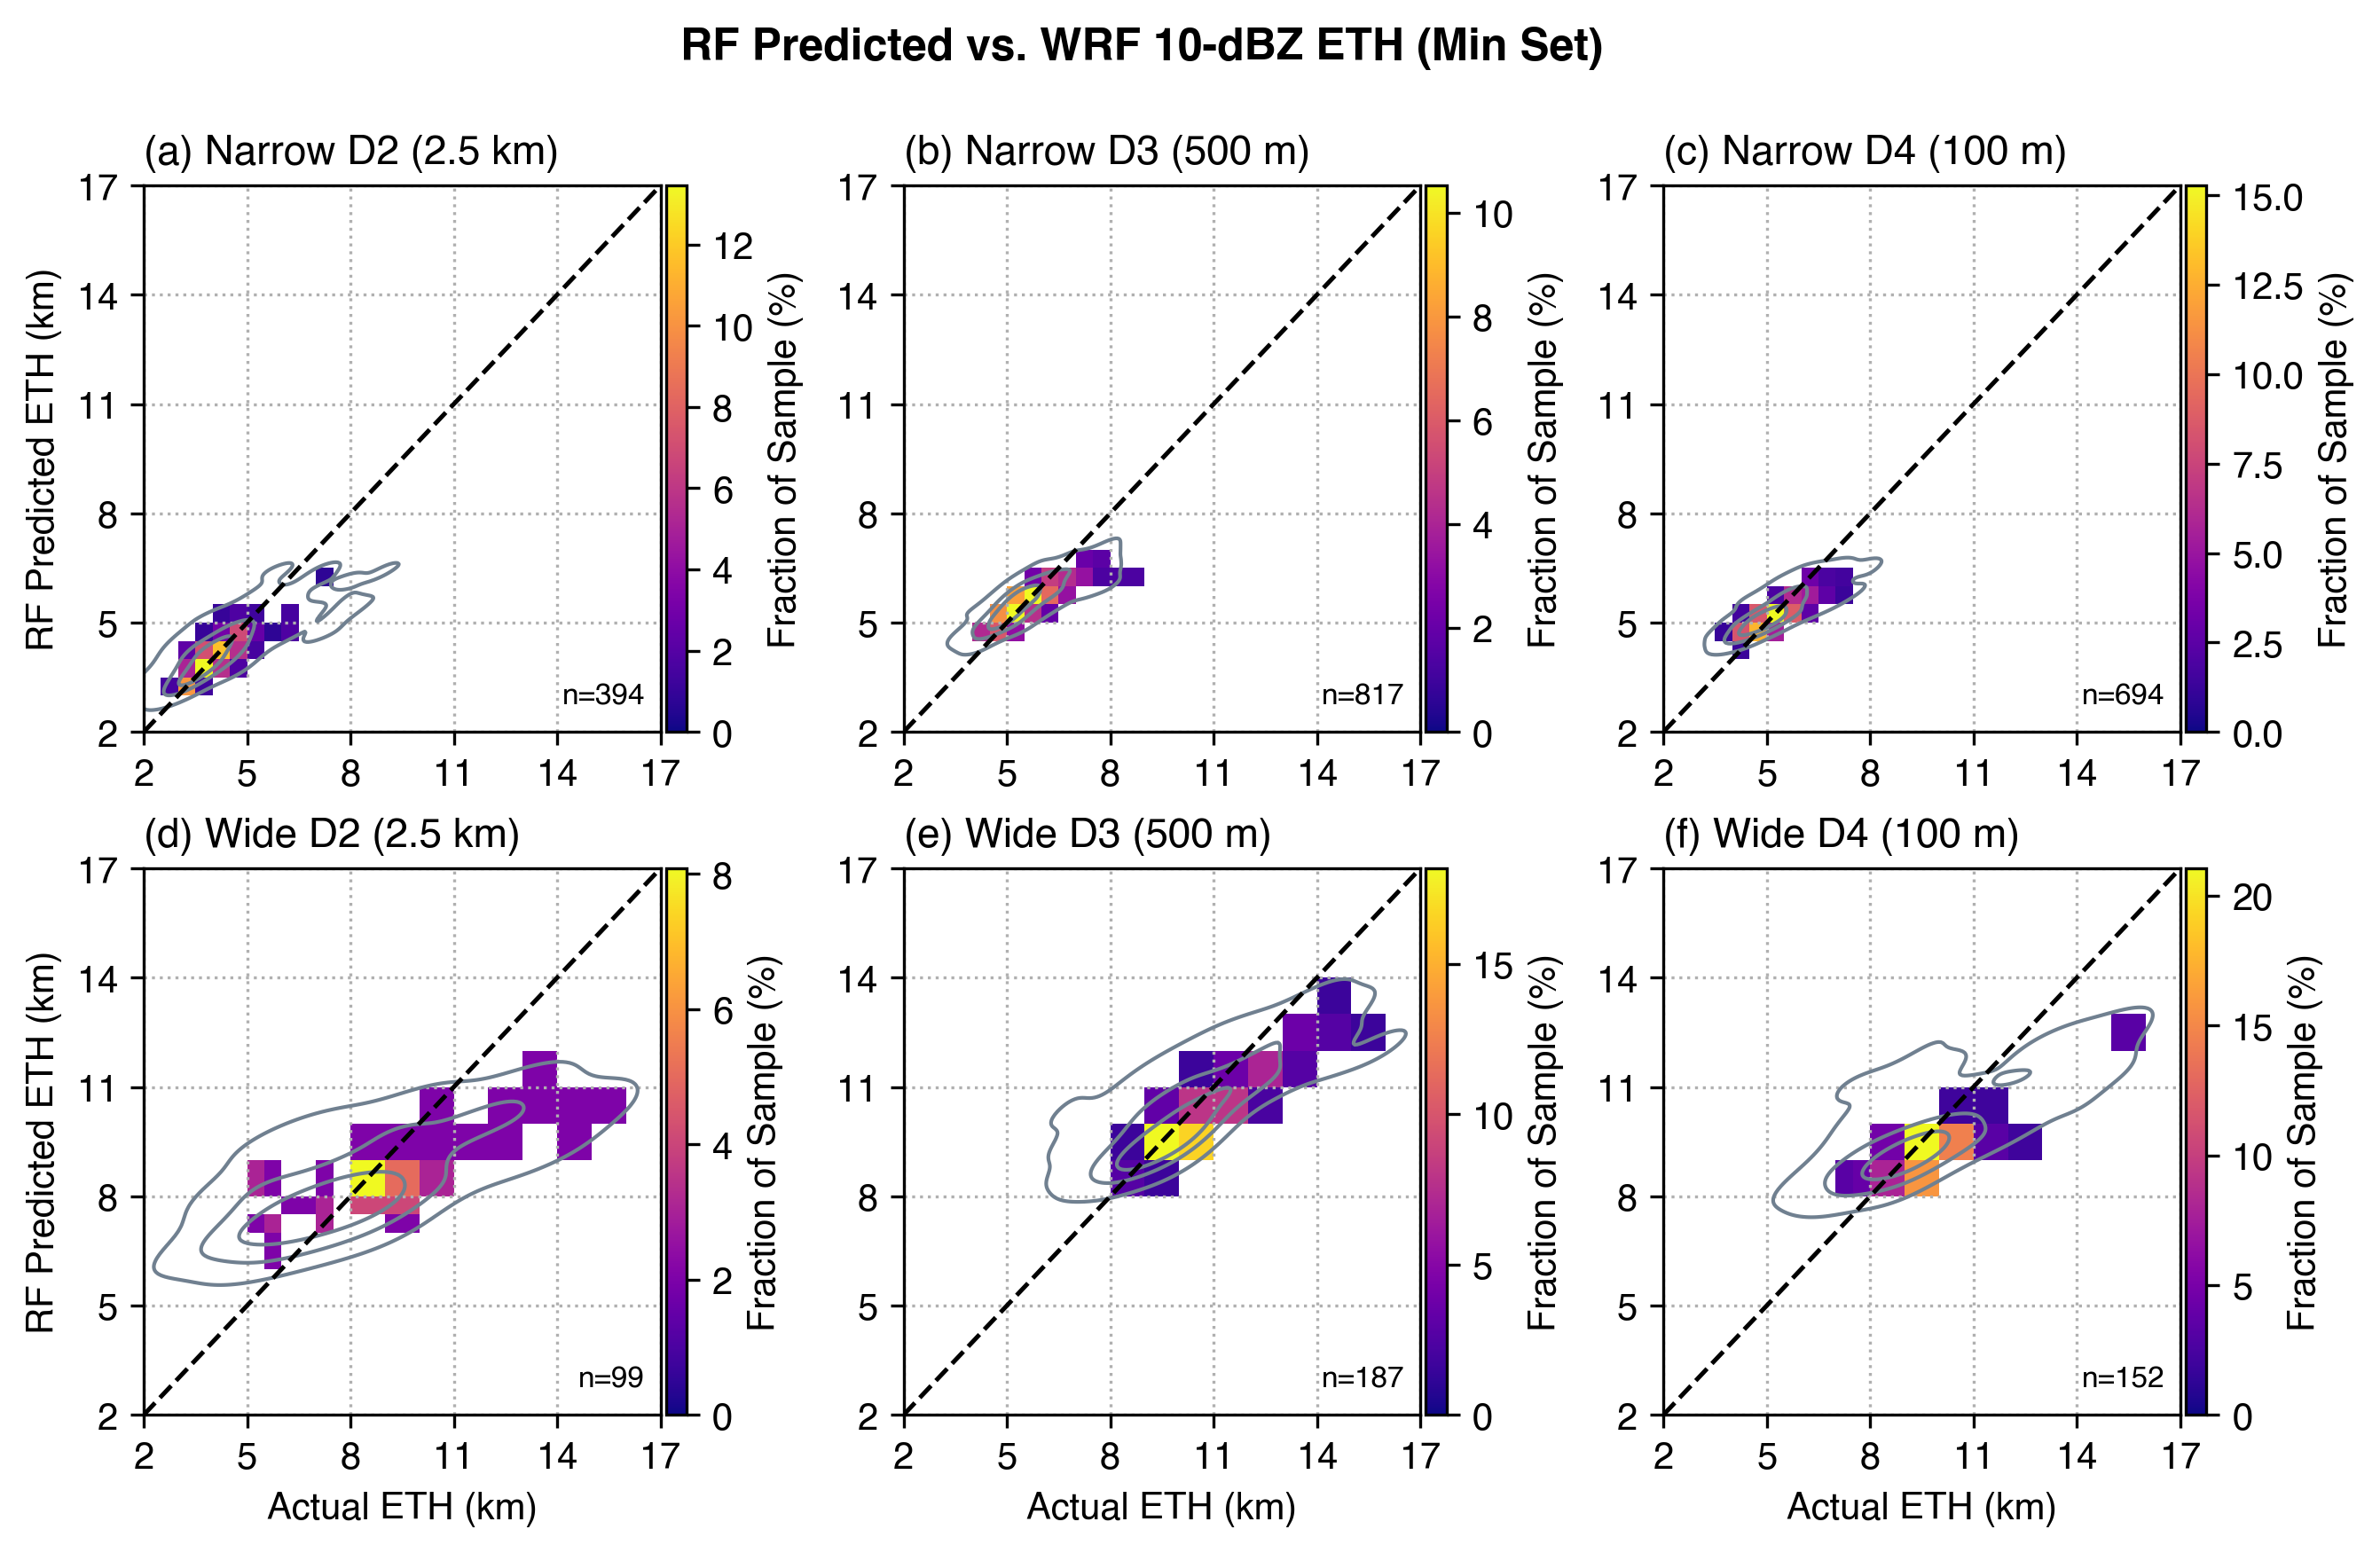

In [57]:
nrow, ncol = 2, 3
ETH_bins = np.hstack((np.arange(0, 8.1, 0.5), np.arange(8, 16.1, 1)))

x_arr_eth_minset = [
    [y_narrow_minset_eth_d2, y_narrow_minset_eth_d3, y_narrow_minset_eth_d4],
    [y_wide_minset_eth_d2,   y_wide_minset_eth_d3,   y_wide_minset_eth_d4],
]
y_arr_eth_minset = [
    [yp_narrow_minset_eth_d2, yp_narrow_minset_eth_d3, yp_narrow_minset_eth_d4],
    [yp_wide_minset_eth_d2,   yp_wide_minset_eth_d3,   yp_wide_minset_eth_d4],
]

bins_hist  = [[ETH_bins] * ncol] * nrow
bin_range  = [[(2, 17)] * ncol] * nrow
xlims      = [[(2, 17)] * ncol] * nrow
ylims      = [[(2, 17)] * ncol] * nrow
xticks_eth = [[np.arange(2, 18, 3)] * ncol] * nrow
yticks_eth = [[np.arange(2, 18, 3)] * ncol] * nrow
cmaps_eth  = [['plasma'] * ncol] * nrow

cbar_labels = [
    ['Fraction of Sample (%)'] * ncol,
    ['Fraction of Sample (%)'] * ncol,
]
kde_levels  = [[4] * ncol] * nrow
kde_colors  = [['slategrey'] * ncol] * nrow

xlabels = [['']*ncol, ['Actual ETH (km)']*ncol]
ylabels = [['RF Predicted ETH (km)', '', '']]*nrow
titles = [
    ['(a) Narrow D2 (2.5 km)', '(b) Narrow D3 (500 m)', '(c) Narrow D4 (100 m)'],
    ['(d) Wide D2 (2.5 km)',   '(e) Wide D3 (500 m)',   '(f) Wide D4 (100 m)'],
]

suptitle = 'RF Predicted vs. WRF 10-dBZ ETH (Min Set)'
figname = f"{figdir}RF_Predicted_vs_Actual_ETH_MinSet.png"
print(figname)
fig = mxn_heatmap(
    nrow, ncol, x_arr_eth_minset, y_arr_eth_minset,
    bins_hist=bins_hist, bin_range=bin_range,
    cmaps=cmaps_eth, cbar_labels=cbar_labels,
    kde_levels=kde_levels, kde_colors=kde_colors,
    xticks=xticks_eth, yticks=yticks_eth,
    xlims=xlims, ylims=ylims,
    xlabels=xlabels, ylabels=ylabels, titles=titles, suptitle=suptitle,
    wspace=0.4, hspace=0.25, fontsize=10, figsize=(10, 6), dpi=300,
    figname=figname,
)

### Predicted vs. Actual — minimal set, Max Updraft Top

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_Predicted_vs_Actual_WTop_MinSet.png
Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_Predicted_vs_Actual_WTop_MinSet.png


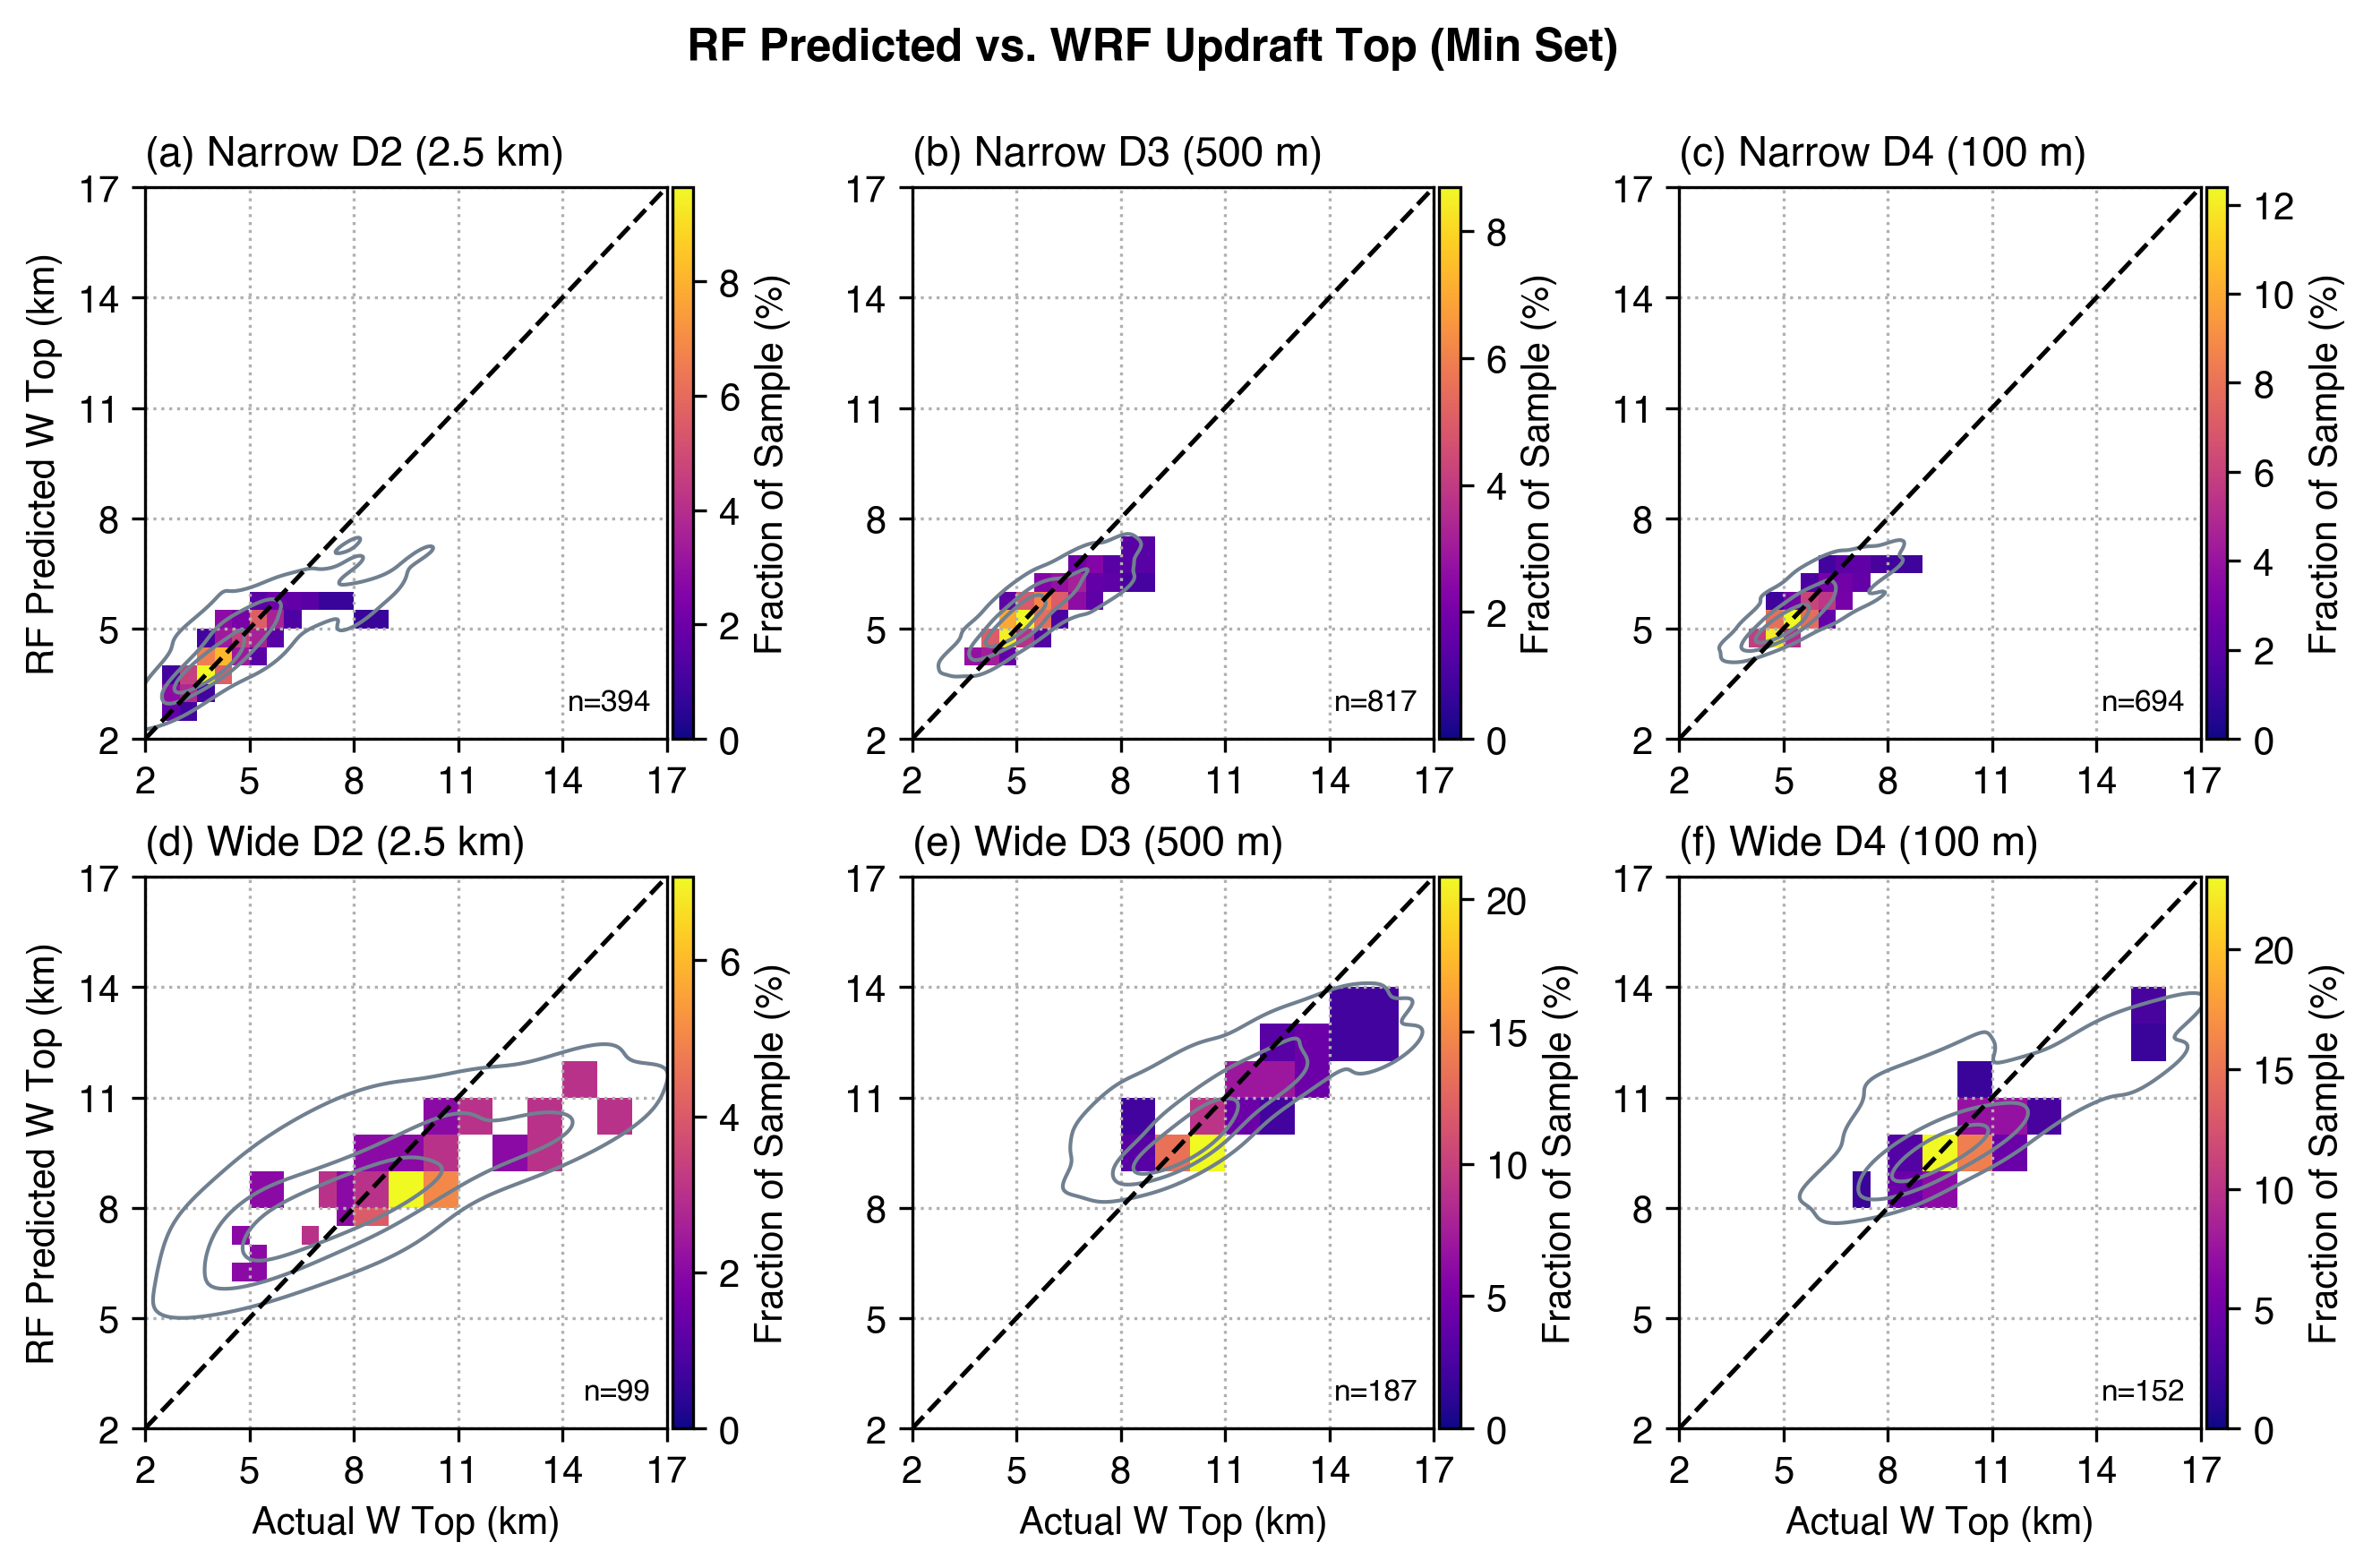

In [58]:
x_arr_wtop_minset = [
    [y_narrow_minset_wtop_d2, y_narrow_minset_wtop_d3, y_narrow_minset_wtop_d4],
    [y_wide_minset_wtop_d2,   y_wide_minset_wtop_d3,   y_wide_minset_wtop_d4],
]
y_arr_wtop_minset = [
    [yp_narrow_minset_wtop_d2, yp_narrow_minset_wtop_d3, yp_narrow_minset_wtop_d4],
    [yp_wide_minset_wtop_d2,   yp_wide_minset_wtop_d3,   yp_wide_minset_wtop_d4],
]

xlabels_wtop = [['']*ncol, ['Actual W Top (km)']*ncol]
ylabels_wtop = [['RF Predicted W Top (km)', '', '']]*nrow
titles_wtop = [
    ['(a) Narrow D2 (2.5 km)', '(b) Narrow D3 (500 m)', '(c) Narrow D4 (100 m)'],
    ['(d) Wide D2 (2.5 km)',   '(e) Wide D3 (500 m)',   '(f) Wide D4 (100 m)'],
]

suptitle = 'RF Predicted vs. WRF Updraft Top (Min Set)'
figname = f"{figdir}RF_Predicted_vs_Actual_WTop_MinSet.png"
print(figname)
fig = mxn_heatmap(
    nrow, ncol, x_arr_wtop_minset, y_arr_wtop_minset,
    bins_hist=bins_hist, bin_range=bin_range,
    cmaps=cmaps_eth, cbar_labels=cbar_labels,
    kde_levels=kde_levels, kde_colors=kde_colors,
    xticks=xticks_eth, yticks=yticks_eth,
    xlims=xlims, ylims=ylims,
    xlabels=xlabels_wtop, ylabels=ylabels_wtop, titles=titles_wtop, suptitle=suptitle,
    wspace=0.4, hspace=0.25, fontsize=10, figsize=(10, 6), dpi=300,
    figname=figname,
)

### Predicted vs. Actual — all predictor set, Max 10-dBZ ETH and Max Updraft Top

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_Predicted_vs_Actual_ETH_AllSet.png
Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_Predicted_vs_Actual_ETH_AllSet.png


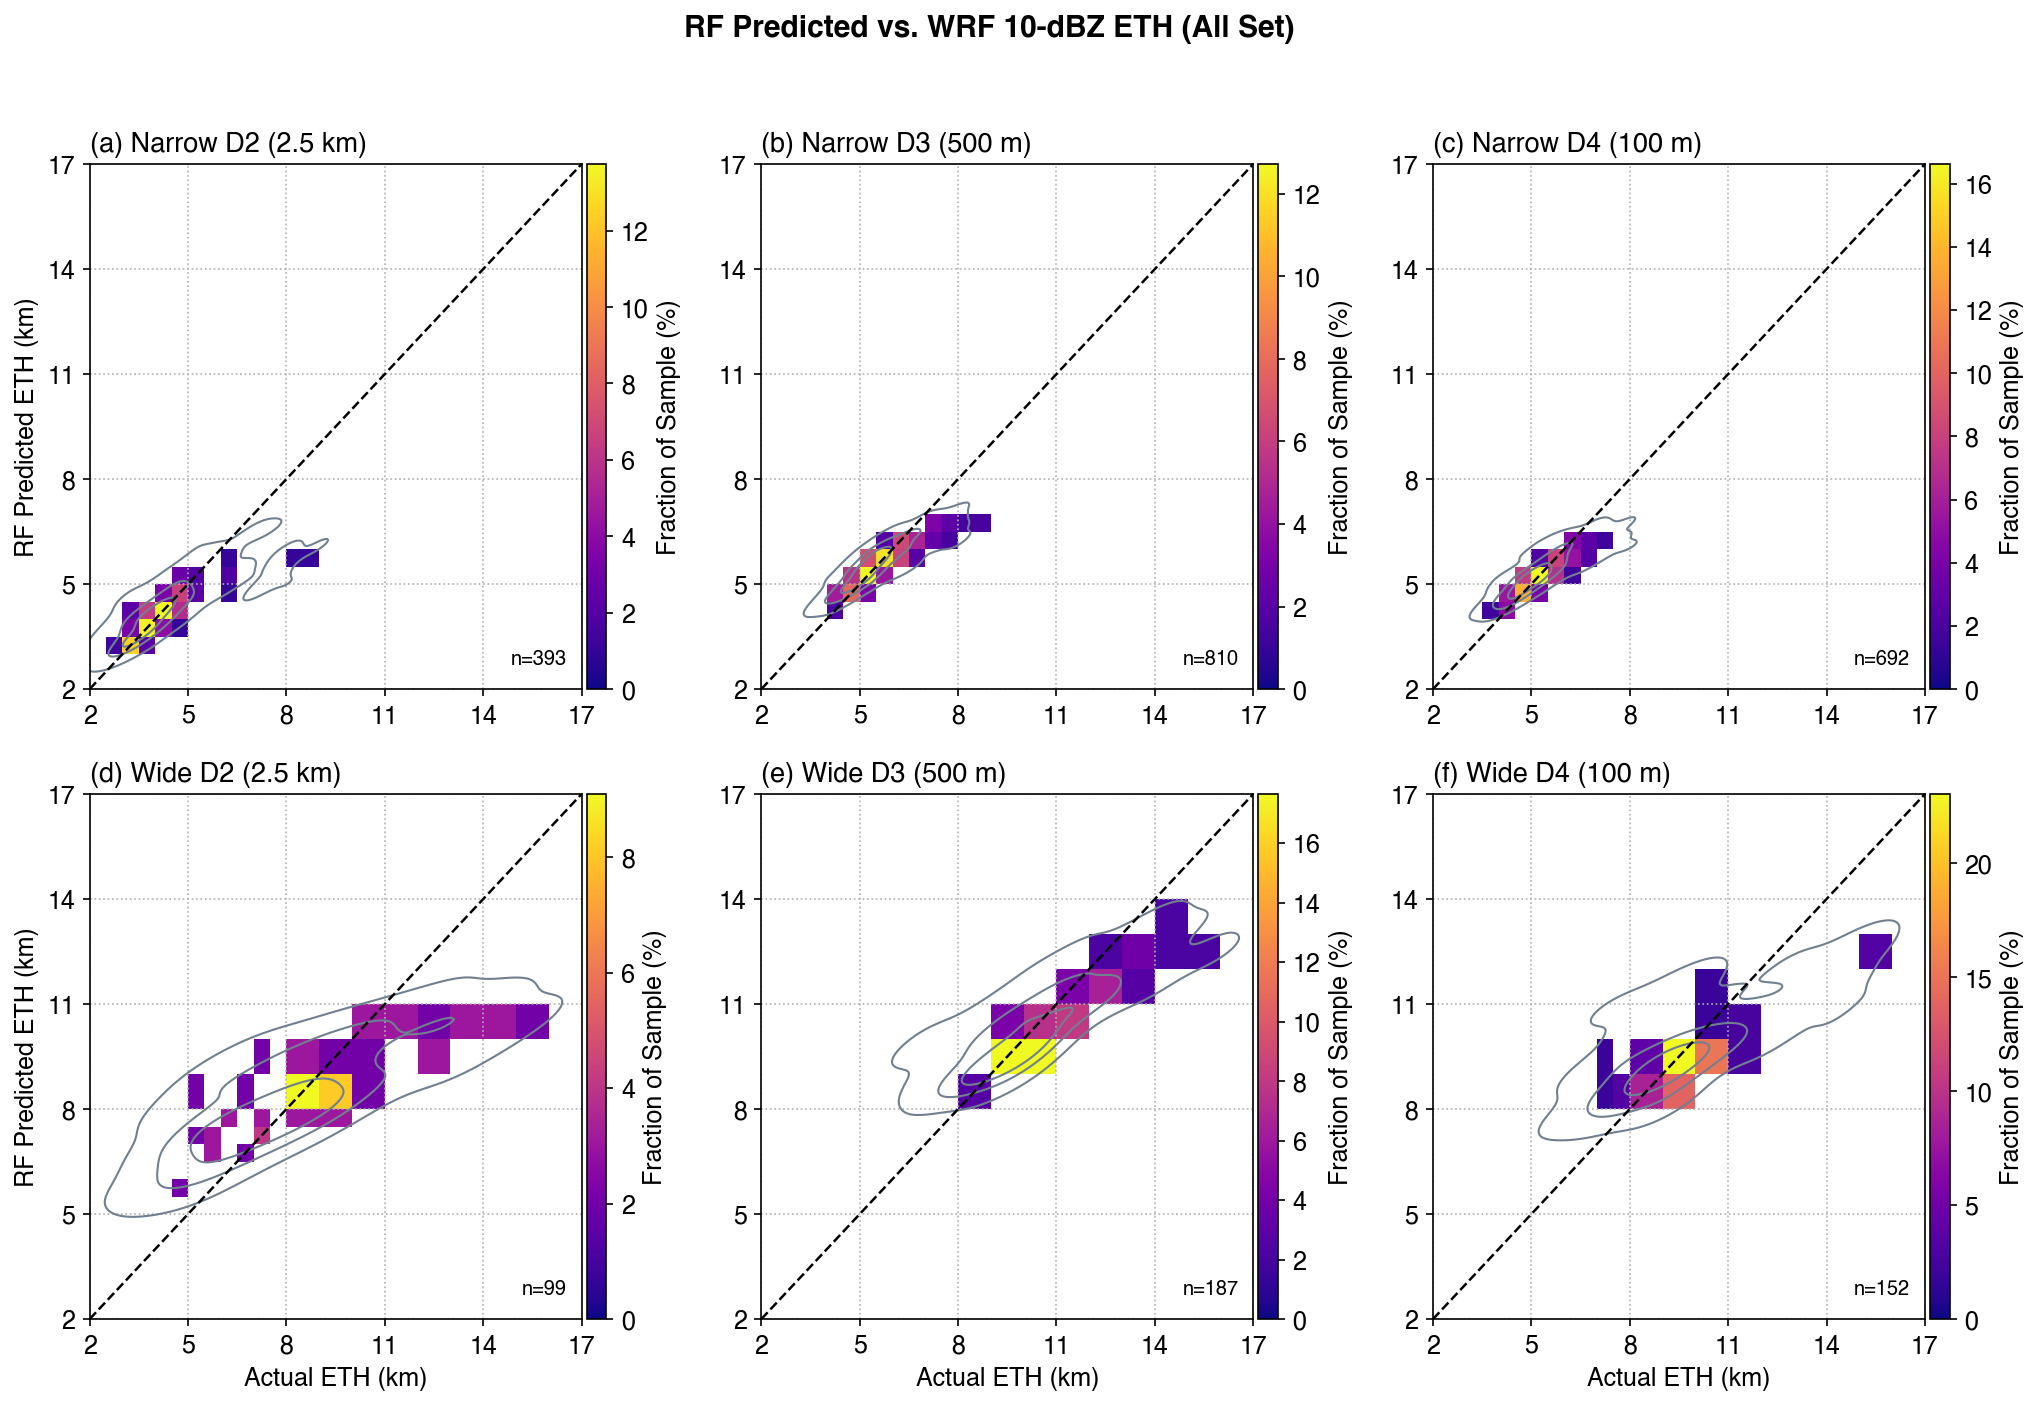

In [59]:
# All-set ETH
x_arr_eth_all = [
    [y_narrow_all_eth_d2, y_narrow_all_eth_d3, y_narrow_all_eth_d4],
    [y_wide_all_eth_d2,   y_wide_all_eth_d3,   y_wide_all_eth_d4],
]
y_arr_eth_all = [
    [yp_narrow_all_eth_d2, yp_narrow_all_eth_d3, yp_narrow_all_eth_d4],
    [yp_wide_all_eth_d2,   yp_wide_all_eth_d3,   yp_wide_all_eth_d4],
]

suptitle = 'RF Predicted vs. WRF 10-dBZ ETH (All Set)'
figname = f"{figdir}RF_Predicted_vs_Actual_ETH_AllSet.png"
print(figname)
fig = mxn_heatmap(
    nrow, ncol, x_arr_eth_all, y_arr_eth_all,
    bins_hist=bins_hist, bin_range=bin_range,
    cmaps=cmaps_eth, cbar_labels=cbar_labels,
    kde_levels=kde_levels, kde_colors=kde_colors,
    xticks=xticks_eth, yticks=yticks_eth,
    xlims=xlims, ylims=ylims,
    xlabels=xlabels, ylabels=ylabels, titles=titles, suptitle=suptitle,
    wspace=0.3, hspace=0.2, fontsize=12, figsize=(16, 10), dpi=150,
    figname=figname,
)

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_Predicted_vs_Actual_WTop_AllSet.png
Saved: /Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures/narrow_wide_CI30min_RF/RF_Predicted_vs_Actual_WTop_AllSet.png


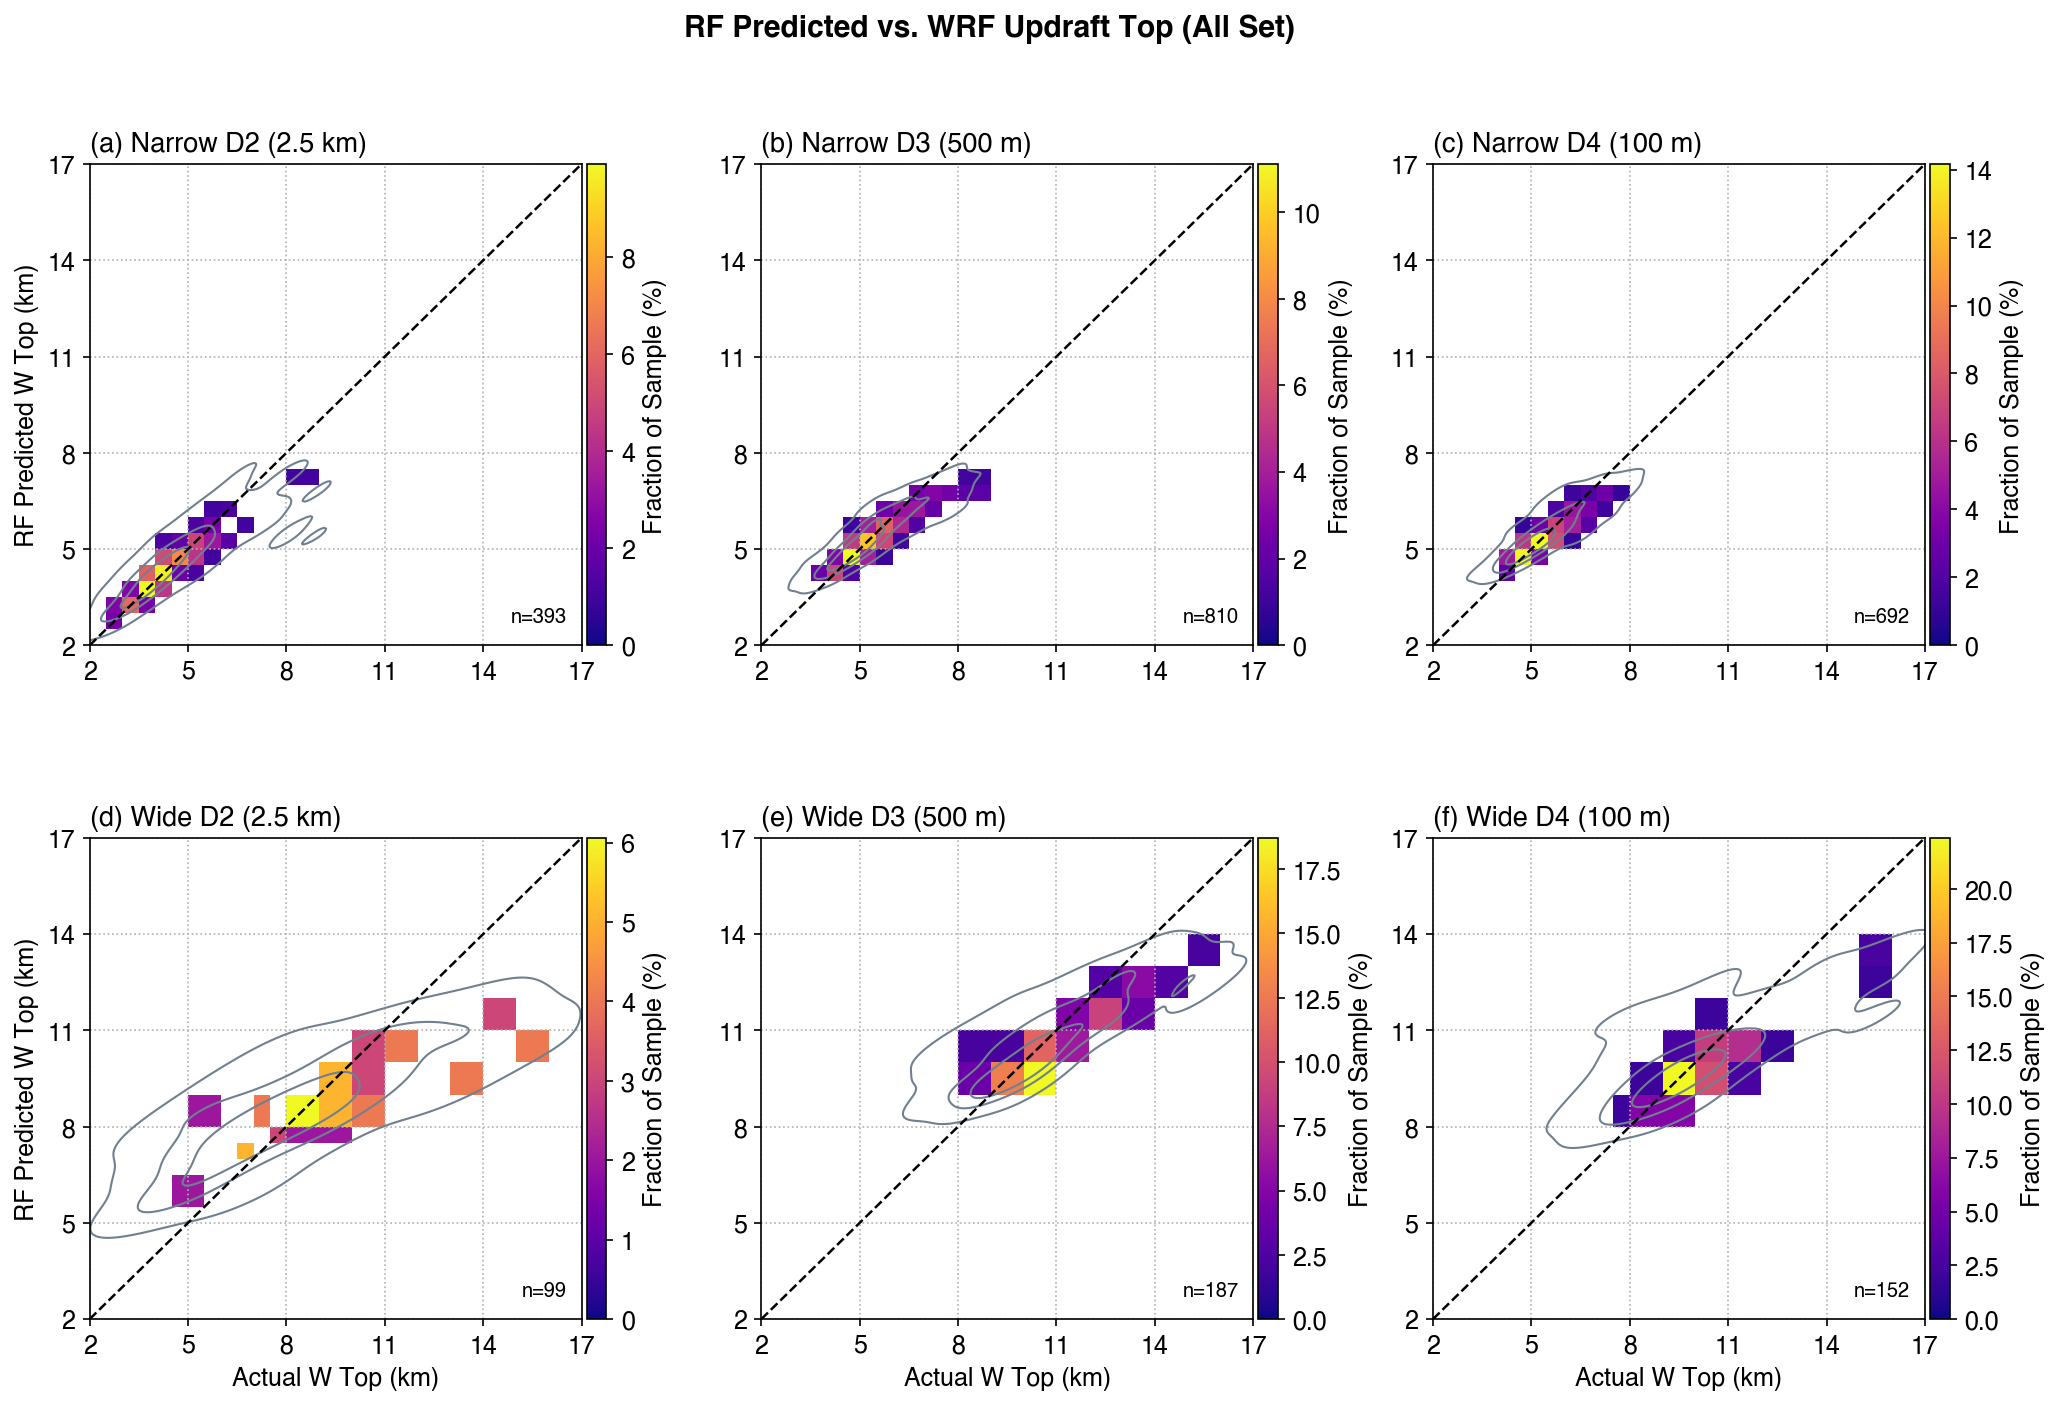

In [60]:
# All-set WTop
x_arr_wtop_all = [
    [y_narrow_all_wtop_d2, y_narrow_all_wtop_d3, y_narrow_all_wtop_d4],
    [y_wide_all_wtop_d2,   y_wide_all_wtop_d3,   y_wide_all_wtop_d4],
]
y_arr_wtop_all = [
    [yp_narrow_all_wtop_d2, yp_narrow_all_wtop_d3, yp_narrow_all_wtop_d4],
    [yp_wide_all_wtop_d2,   yp_wide_all_wtop_d3,   yp_wide_all_wtop_d4],
]

suptitle = 'RF Predicted vs. WRF Updraft Top (All Set)'
figname = f"{figdir}RF_Predicted_vs_Actual_WTop_AllSet.png"
print(figname)
fig = mxn_heatmap(
    nrow, ncol, x_arr_wtop_all, y_arr_wtop_all,
    bins_hist=bins_hist, bin_range=bin_range,
    cmaps=cmaps_eth, cbar_labels=cbar_labels,
    kde_levels=kde_levels, kde_colors=kde_colors,
    xticks=xticks_eth, yticks=yticks_eth,
    xlims=xlims, ylims=ylims,
    xlabels=xlabels_wtop, ylabels=ylabels_wtop, titles=titles_wtop, suptitle=suptitle,
    wspace=0.3, hspace=0.4, fontsize=12, figsize=(16, 10), dpi=150,
    figname=figname,
)